# Подготовка и анализ результатов исследования алгоритмов поиска пути на плоскости с круговыми препятствиями

#### Дополнение к дипломной работе "Структурные и геометрические параметры среды в алгоритмах поиска пути на плоскости с круговыми препятствиями" студента Павлючика Антона Михайловича 

Этот ноутбук посвящён обработке и анализу результатов, полученных в ходе экспериментального исследования алгоритмов поиска пути.

В ноутбуке выполняются парсинг файлов экспериментов, фильтрация и подготовка данных, построение аналитического датасета, визуальный и статистический анализ результатов, а также формулировка основных выводов и практических рекомендаций.

Подключение библиотек и парсера

In [ ]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display
from tools import experiment_dataset_parser as experiment_dataset_parser

save_dataset_bundle = experiment_dataset_parser.save_dataset_bundle
experiment_dataset_parser = importlib.reload(experiment_dataset_parser)
build_experiment_dataset = experiment_dataset_parser.build_experiment_dataset
build_analysis_run_dataset = experiment_dataset_parser.build_analysis_run_dataset

In [78]:
EXPERIMENTS_DIR = Path('configs/studies/final_25/experiment_runs')
OUTPUT_DIR = Path('analysis_outputs')
DATASET_PREFIX = 'final25'

bundle = build_experiment_dataset(EXPERIMENTS_DIR)
analysis_run_df = getattr(bundle, 'analysis_run_df', None)
if analysis_run_df is None:
    analysis_run_df = build_analysis_run_dataset(bundle.run_df)

summary = dict(getattr(bundle, 'summary', {}))
summary.setdefault('analysis_run_row_count', int(len(analysis_run_df)))
summary.setdefault('executed_run_count', int(bundle.run_df['algorithm_was_executed'].fillna(False).sum()))
summary.setdefault('not_run_count', int((bundle.run_df['algorithm_status'] == 'NotRun').sum()))
summary.setdefault('scene_row_count', int(len(bundle.scene_df)))
summary_df = pd.DataFrame([summary])

display(summary_df)
display(bundle.file_df.head())

,experiment_file_count,run_row_count,analysis_run_row_count,scene_row_count,theoretical_max_run_rows,actual_run_rows,executed_run_count,not_run_count,generated_scene_count,completed_scene_count,path_found_run_count,failed_run_count
0,53,212000,212000,42400,212000,212000,211685,315,42337,42337,202284,0


,experiment_file,experiment_path,config_index,experiment_name,config_name,experiment_status,scene_count_declared,actual_scene_rows,generated_scene_count,completed_scene_count,any_path_scene_count,enabled_algorithm_count,theoretical_max_run_rows,actual_run_rows,executed_run_count,not_run_count,path_found_run_count,failed_run_count
0,exp_config_01_experiment.json,configs\studies\final_25\experiment_runs\exp_c...,1,final25_compact_uniform_micro_open,final25_compact_uniform_micro_open,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
1,exp_config_02_experiment.json,configs\studies\final_25\experiment_runs\exp_c...,2,final25_compact_uniform_micro_balanced_dense,final25_compact_uniform_micro_balanced_dense,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
2,exp_config_03_experiment.json,configs\studies\final_25\experiment_runs\exp_c...,3,final25_compact_uniform_dense_wide_radii,final25_compact_uniform_dense_wide_radii,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
3,exp_config_04_experiment.json,configs\studies\final_25\experiment_runs\exp_c...,4,final25_compact_mixed_scale_patchy_large,final25_compact_mixed_scale_patchy_large,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
4,exp_config_05_experiment.json,configs\studies\final_25\experiment_runs\exp_c...,5,final25_medium_large_disks_sparse_plus,final25_medium_large_disks_sparse_plus,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0


Успешно спарсили и прочитали файлы экспериментов, уточним ещё некоторые параметры

In [109]:
print('Строк-слотов алгоритмов:', bundle.summary['analysis_run_row_count'])
print('Выполненных запусков:', bundle.summary['executed_run_count'])
print('NotRun-слотов:', bundle.summary['not_run_count'])
print('Строк сцен:', bundle.summary['scene_row_count'])

saved_paths = save_dataset_bundle(bundle, OUTPUT_DIR, prefix=DATASET_PREFIX)
saved_paths

Строк-слотов алгоритмов: 212000
Выполненных запусков: 211685
NotRun-слотов: 315
Строк сцен: 42400


{'runs': 'analysis_outputs\\final25_runs.parquet',
 'runs_analysis': 'analysis_outputs\\final25_runs_analysis.parquet',
 'scenes': 'analysis_outputs\\final25_scenes.parquet',
 'files': 'analysis_outputs\\final25_files.parquet',
 'summary': 'analysis_outputs\\final25_summary.json'}

Сформируем мастер-датасет, который и и данные из которого будем анализировать. Выберем данные и из буфера сформируем датасет

In [80]:
HEAD_COLUMNS = [
    'config_index',
    'config_name',
    'scene_id',
    'scene_index',
    'scene_seed',
    'scene_generation_status',
    'scene_run_status',
    'scene_width',
    'scene_height',
    'scene_obstacle_count',
    'scene_direct_distance',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'path_length',
    'relative_path_length',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'algorithm_params_json',
]

missing_columns = [column for column in HEAD_COLUMNS if column not in analysis_run_df.columns]
if missing_columns:
    raise KeyError(f'Missing columns in analysis_run_df: {missing_columns}')

analysis_view_df = analysis_run_df[HEAD_COLUMNS].copy()
analysis_view_df.shape

(212000, 25)

In [81]:
display(analysis_view_df.head(15))

,config_index,config_name,scene_id,scene_index,scene_seed,scene_generation_status,scene_run_status,scene_width,scene_height,scene_obstacle_count,...,runtime_ms,path_length,relative_path_length,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio,algorithm_params_json
0,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,12.1930,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
1,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,12.3522,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
2,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,0.0161,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""enable_path_smoothing"": true, ""goal_sample_r..."
3,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,80.0910,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""points_per_obstacle"": 16}"
4,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,84.4803,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""points_per_obstacle"": 16}"
5,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,11.7645,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
6,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,12.2405,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
7,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,0.0086,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""enable_path_smoothing"": true, ""goal_sample_r..."
8,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,66.9120,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""points_per_obstacle"": 16}"
9,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,71.1169,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""points_per_obstacle"": 16}"


Получили нужные данные, теперь компактизируем датасет и начнём анализ.

## Выборка данных

Ниже формируется отдельный компактный датасет по выбранным колонкам. Он сохраняется в `analysis_outputs` и используется как удобная основа для дальнейшего анализа.

In [ ]:
COMPACT_ANALYSIS_COLUMNS = [
    'scene_generation_status',
    'scene_run_status',
    'scene_direct_distance',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'path_length',
    'relative_path_length',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
]

missing_compact_columns = [
    column for column in COMPACT_ANALYSIS_COLUMNS if column not in analysis_run_df.columns
]

Compact dataset rows: 212000
Compact dataset columns: 16
Saved to: analysis_outputs\final25_runs_compact.parquet


(212000, 16)

In [83]:
with pd.option_context('display.max_columns', None, 'display.width', 2000, 'display.max_colwidth', 200):
    display(analysis_compact_df.head(15))

,scene_generation_status,scene_run_status,scene_direct_distance,algorithm_id,algorithm_status,algorithm_was_executed,path_found,runtime_ms,path_length,relative_path_length,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio
0,Generated,Completed,68.126456,grid_astar,Success,True,True,12.1930,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
1,Generated,Completed,68.126456,grid_dijkstra,Success,True,True,12.3522,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
2,Generated,Completed,68.126456,rrt,Success,True,True,0.0161,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
3,Generated,Completed,68.126456,visibility_astar,Success,True,True,80.0910,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
4,Generated,Completed,68.126456,visibility_dijkstra,Success,True,True,84.4803,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
5,Generated,Completed,91.411125,grid_astar,Success,True,True,11.7645,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
6,Generated,Completed,91.411125,grid_dijkstra,Success,True,True,12.2405,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
7,Generated,Completed,91.411125,rrt,Success,True,True,0.0086,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
8,Generated,Completed,91.411125,visibility_astar,Success,True,True,66.9120,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
9,Generated,Completed,91.411125,visibility_dijkstra,Success,True,True,71.1169,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0


Перейдём к интепретации данных

## Интерпретация метрик пути

`path_length` - абсолютная длина найденного пути в координатах сцены.

`relative_path_length` - отношение длины найденного пути к прямому расстоянию между стартом и целью: `path_length / direct_distance(start, goal)`

Если значение близко к 1, маршрут почти прямой. Чем оно больше, тем сильнее алгоритм вынужден обходить препятствия

## Вариативность метрик среды

Для анализа разнообразия сред целесообразно перейти к представлению **одна строка = одна сцена**, чтобы не дублировать метрики по всем алгоритмам. Ниже строится отдельный scene-level срез только для успешно сгенерированных сцен.

Также расчитаем характеристики и распределения метрик сцен, чтобы оценить уровень покрытия различных ситуаций для тестов алгоритмов.

In [112]:
SCENE_METRIC_COLUMNS = [
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_radii_cv',
]

SCENE_ANALYSIS_COLUMNS = [
    'config_index',
    'config_name',
    'scene_id',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_obstacle_count',
    'scene_direct_distance',
    *SCENE_METRIC_COLUMNS,
]

In [113]:
scene_analysis_df = bundle.scene_df.loc[
    bundle.scene_df['scene_is_generated'].fillna(False),
    SCENE_ANALYSIS_COLUMNS,
].copy()
scene_analysis_df = scene_analysis_df.sort_values(['config_index', 'scene_id']).reset_index(drop=True)

scene_analysis_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_analysis.parquet'
scene_analysis_df.to_parquet(scene_analysis_path, index=False)

variability_summary_df = pd.DataFrame({
    'metric': SCENE_METRIC_COLUMNS,
    'min': [scene_analysis_df[c].min() for c in SCENE_METRIC_COLUMNS],
    'p05': [scene_analysis_df[c].quantile(0.05) for c in SCENE_METRIC_COLUMNS],
    'median': [scene_analysis_df[c].median() for c in SCENE_METRIC_COLUMNS],
    'p95': [scene_analysis_df[c].quantile(0.95) for c in SCENE_METRIC_COLUMNS],
    'max': [scene_analysis_df[c].max() for c in SCENE_METRIC_COLUMNS],
    'std': [scene_analysis_df[c].std() for c in SCENE_METRIC_COLUMNS],
    'n_unique': [scene_analysis_df[c].nunique() for c in SCENE_METRIC_COLUMNS],
    'share_eq_1': [(scene_analysis_df[c] == 1.0).mean() for c in SCENE_METRIC_COLUMNS],
    'share_lt_0_95': [(scene_analysis_df[c] < 0.95).mean() for c in SCENE_METRIC_COLUMNS],
})

In [114]:
variability_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_variability.csv'
variability_summary_df.to_csv(variability_summary_path, index=False)

print('Scene-level dataset rows:', len(scene_analysis_df))
print('Scene-level dataset saved to:', scene_analysis_path)
print('Variability summary saved to:', variability_summary_path)
print('largest_component_ratio == 1 share:', 
      round((scene_analysis_df['scene_metric_largest_component_ratio'] == 1.0).mean(), 4))
print('largest_component_ratio < 0.95 share:', 
      round((scene_analysis_df['scene_metric_largest_component_ratio'] < 0.95).mean(), 4))

with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(variability_summary_df)

Scene-level dataset rows: 42337
Scene-level dataset saved to: analysis_outputs\final25_scene_analysis.parquet
Variability summary saved to: analysis_outputs\final25_scene_metric_variability.csv
largest_component_ratio == 1 share: 0.2806
largest_component_ratio < 0.95 share: 0.0456


,metric,min,p05,median,p95,max,std,n_unique,share_eq_1,share_lt_0_95
0,scene_metric_boundary_density,2.876100e-03,0.007295,0.037545,0.147262,0.236808,0.043097,42287,0.000000,1.000000
1,scene_metric_cell_density_cv,4.027139e-01,0.567605,1.272352,2.162150,3.151623,0.512483,42337,0.000000,0.316839
2,scene_metric_clearance,3.413086e-01,0.557702,1.928571,6.684581,12.336596,2.016210,26669,0.000850,0.169757
3,scene_metric_largest_component_ratio,2.437164e-01,0.956706,0.999770,1.000000,1.000000,0.051734,26518,0.280558,0.045610
4,scene_metric_obstacle_area_ratio,1.490000e-02,0.035800,0.161600,0.482300,0.735200,0.149236,5736,0.000000,1.000000
5,scene_metric_radii_cv,6.055762e-16,0.172754,0.313335,0.413840,0.550204,0.074521,41539,0.000000,1.000000


Построим графики для оценки существующих наборов метрик.

Saved: analysis_outputs\final25_scene_metric_histograms.png


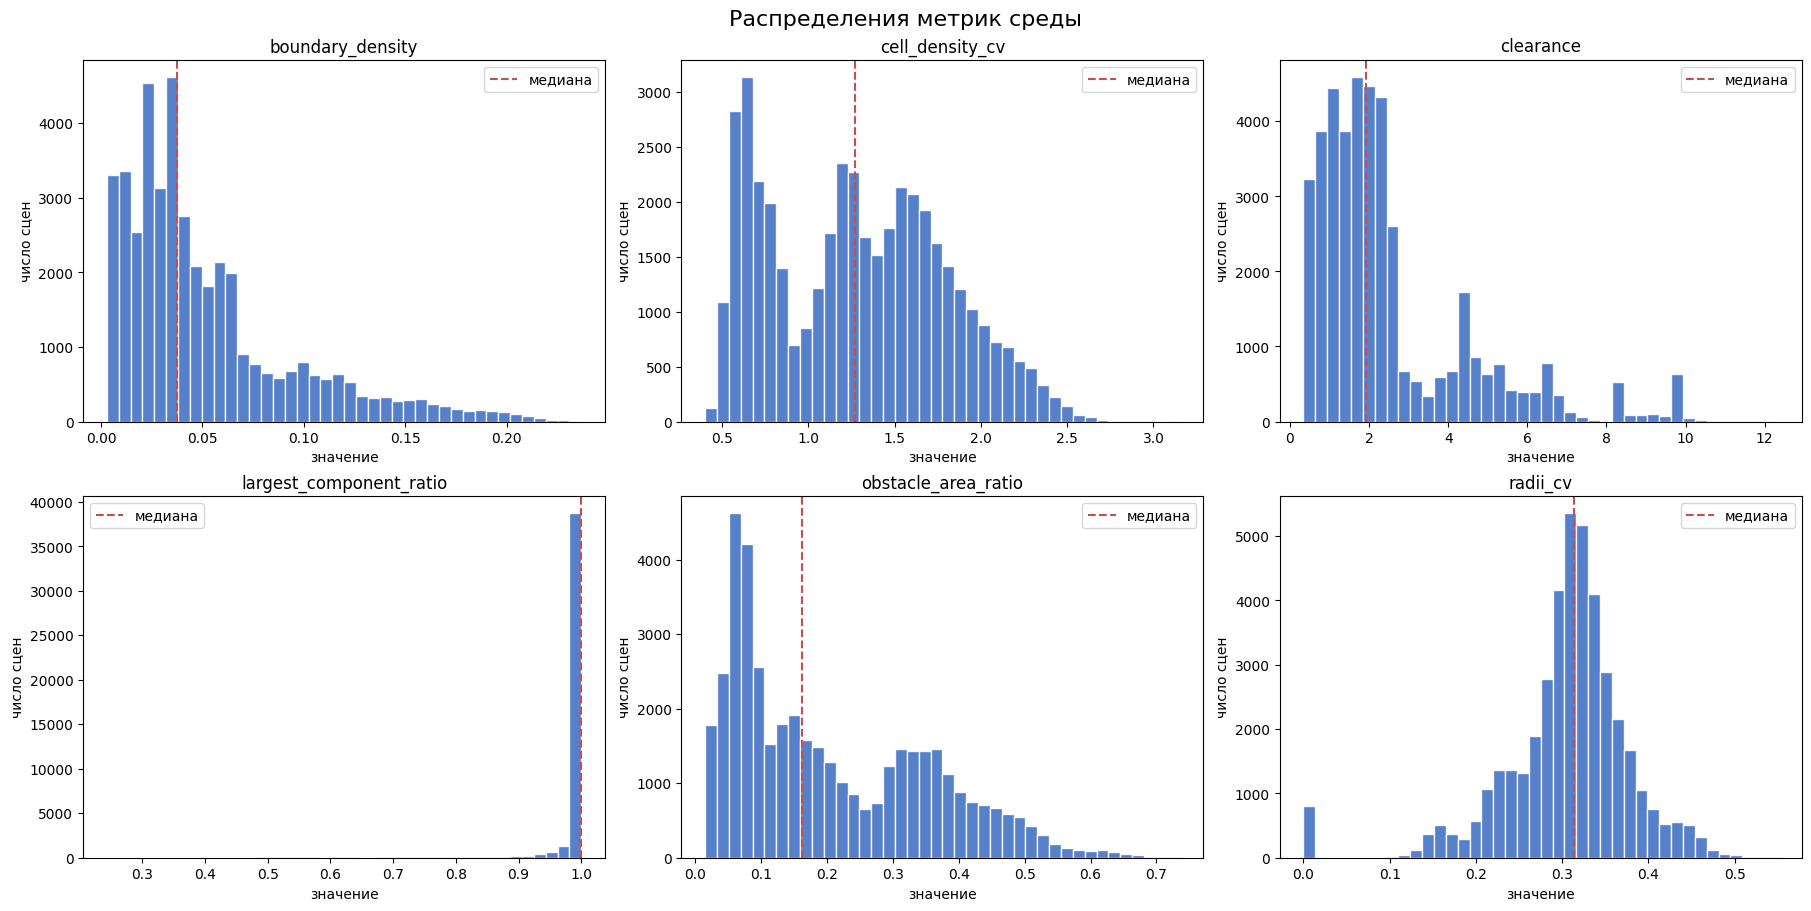

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, SCENE_METRIC_COLUMNS):
    values = scene_analysis_df[metric]
    ax.hist(values, bins=40, color='#4472c4', edgecolor='white', alpha=0.9)
    ax.axvline(values.median(), color='#c44e52', linestyle='--', linewidth=1.5, label='медиана')
    ax.set_title(metric.replace('scene_metric_', ''))
    ax.set_xlabel('значение')
    ax.set_ylabel('число сцен')
    ax.legend(loc='best')

fig.suptitle('Распределения метрик среды', fontsize=16)
metric_hist_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_histograms.png'
fig.savefig(metric_hist_path, dpi=180, bbox_inches='tight')
print('Saved:', metric_hist_path)
plt.show()

Распределения метрик среды в целом выглядят достаточно разнообразными и пригодными для анализа. Они не схлопнулись в константы, а значит сцены действительно различаются по структуре и сложности.

Для boundary_density, cell_density_cv, clearance и obstacle_area_ratio на графиках виден заметный разброс значений, что говорит о наличии в наборе как более простых, так и более сложных конфигураций среды. Это делает метрики содержательно полезными для сопоставления с результатами алгоритмов.

Для largest_component_ratio заметен выраженный пик вблизи 1.0. Это ожидаемо, поскольку значительная часть конфигов всё же ориентирована на проходимые и связные сцены. При этом метрика не вырождается полностью: сохраняется хвост меньших значений, соответствующий более сложным и частично фрагментированным случаям.

Отдельные пики и локальные сгущения на графиках в целом естественны и, вероятно, связаны с тем, что набор состоит из разных семейств конфигов с различной структурой сцен. Иными словами, это отражает не артефакт, а смешение нескольких типов сред в одной экспериментальной базе.

Для radii_cv вариативность выражена слабее, чем у остальных метрик, однако распределение всё равно не сводится к одному значению. В целом полученная картина не идеальна с точки зрения равномерности, но вполне достаточна для дальнейшего содержательного анализа.

Поскольку набор конфигураций и полученные метрики можно назвать пригодными для анализа. Выясним практические взаимосвязи между ними

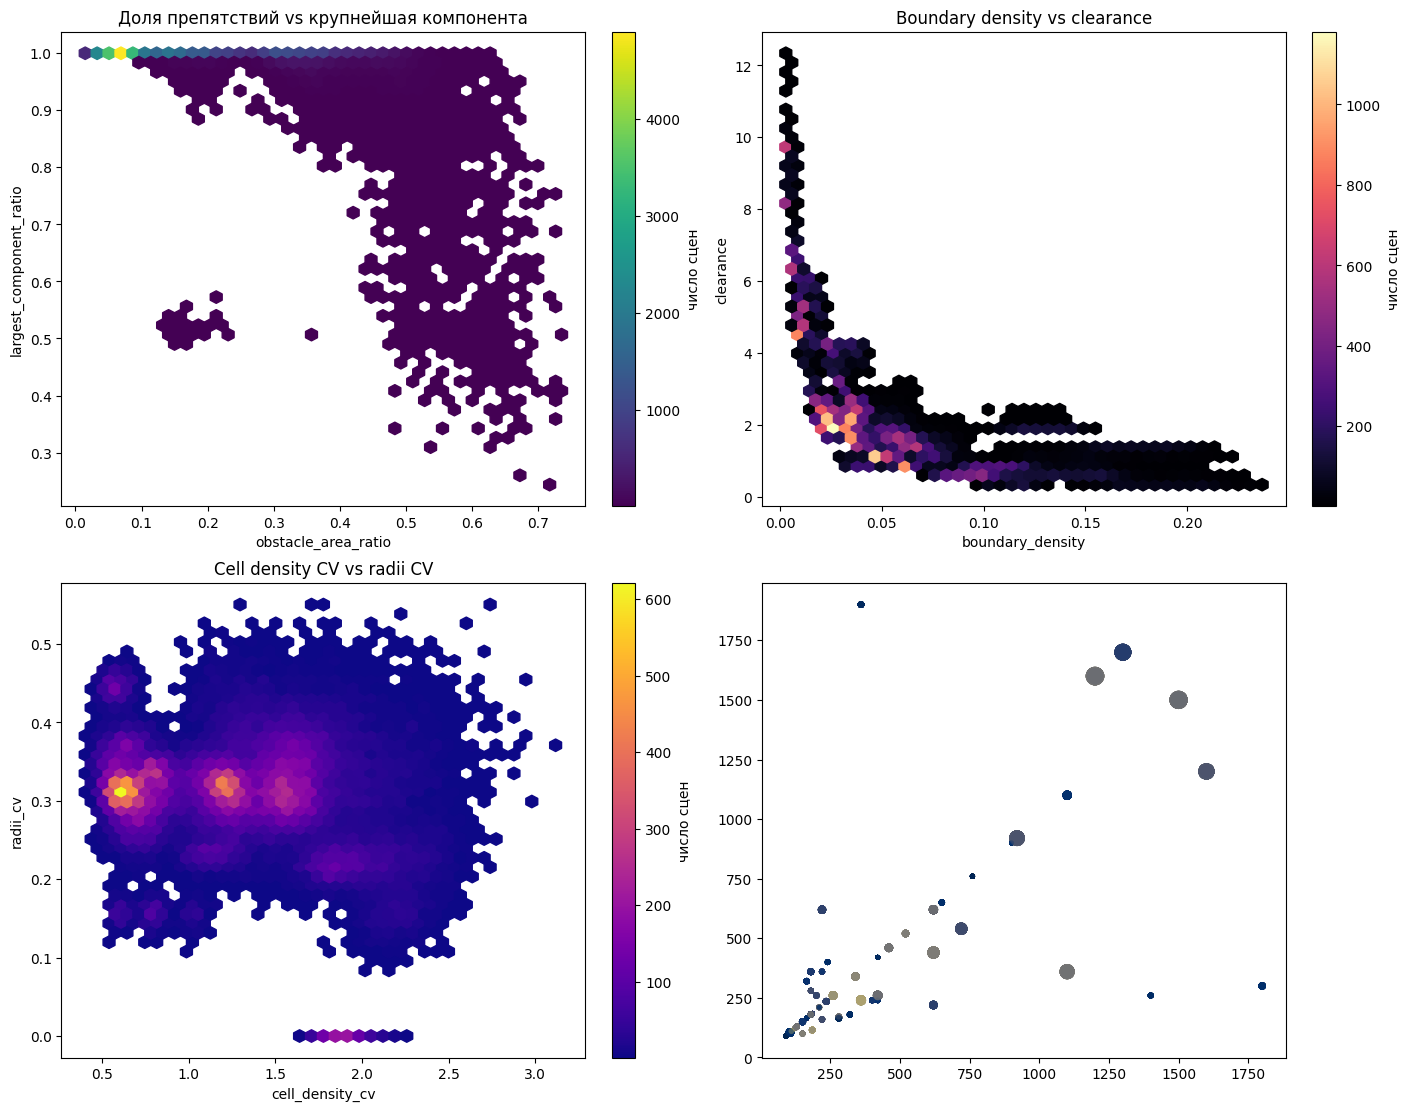

In [116]:
sample_size = min(10000, len(scene_analysis_df))
scatter_df = scene_analysis_df.sample(sample_size, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)

hb = axes[0, 0].hexbin(
    scene_analysis_df['scene_metric_obstacle_area_ratio'],
    scene_analysis_df['scene_metric_largest_component_ratio'],
    gridsize=40,
    cmap='viridis',
    mincnt=1,
)
axes[0, 0].set_title('Доля препятствий vs крупнейшая компонента')
axes[0, 0].set_xlabel('obstacle_area_ratio')
axes[0, 0].set_ylabel('largest_component_ratio')
fig.colorbar(hb, ax=axes[0, 0], label='число сцен')

hb = axes[0, 1].hexbin(
    scene_analysis_df['scene_metric_boundary_density'],
    scene_analysis_df['scene_metric_clearance'],
    gridsize=40,
    cmap='magma',
    mincnt=1,
)
axes[0, 1].set_title('Boundary density vs clearance')
axes[0, 1].set_xlabel('boundary_density')
axes[0, 1].set_ylabel('clearance')
fig.colorbar(hb, ax=axes[0, 1], label='число сцен')

hb = axes[1, 0].hexbin(
    scene_analysis_df['scene_metric_cell_density_cv'],
    scene_analysis_df['scene_metric_radii_cv'],
    gridsize=40,
    cmap='plasma',
    mincnt=1,
)
axes[1, 0].set_title('Cell density CV vs radii CV')
axes[1, 0].set_xlabel('cell_density_cv')
axes[1, 0].set_ylabel('radii_cv')
fig.colorbar(hb, ax=axes[1, 0], label='число сцен')

scatter = axes[1, 1].scatter(
    scatter_df['scene_width'],
    scatter_df['scene_height'],
    c=scatter_df['scene_metric_obstacle_area_ratio'],
    s=np.clip(scatter_df['scene_obstacle_count'] / 3.0, 12, 220),
    alpha=0.35,
    cmap='cividis',
    edgecolors='none',
)

In [117]:
axes[1, 1].set_title('Геометрическое разнообразие сцен')
axes[1, 1].set_xlabel('ширина сцены')
axes[1, 1].set_ylabel('высота сцены')
fig.colorbar(scatter, ax=axes[1, 1], label='obstacle_area_ratio')

fig.suptitle('Связи между метриками среды', fontsize=16)
metric_relation_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_relationships.png'
fig.savefig(metric_relation_path, dpi=180, bbox_inches='tight')
print('Saved:', metric_relation_path)
plt.show()

Saved: analysis_outputs\final25_scene_metric_relationships.png


На видно, что рост плотности и покрытия препятствиями связан с ухудшением связности и уменьшением clearance. При этом радиусная вариативность не полностью совпадает с плотностными характеристиками, а значит остаётся самостоятельной осью сложности.

Произведём z-оценку конфигов для сравнения вариативности сцен в конфигах

Saved: analysis_outputs\final25_config_metric_heatmap.png


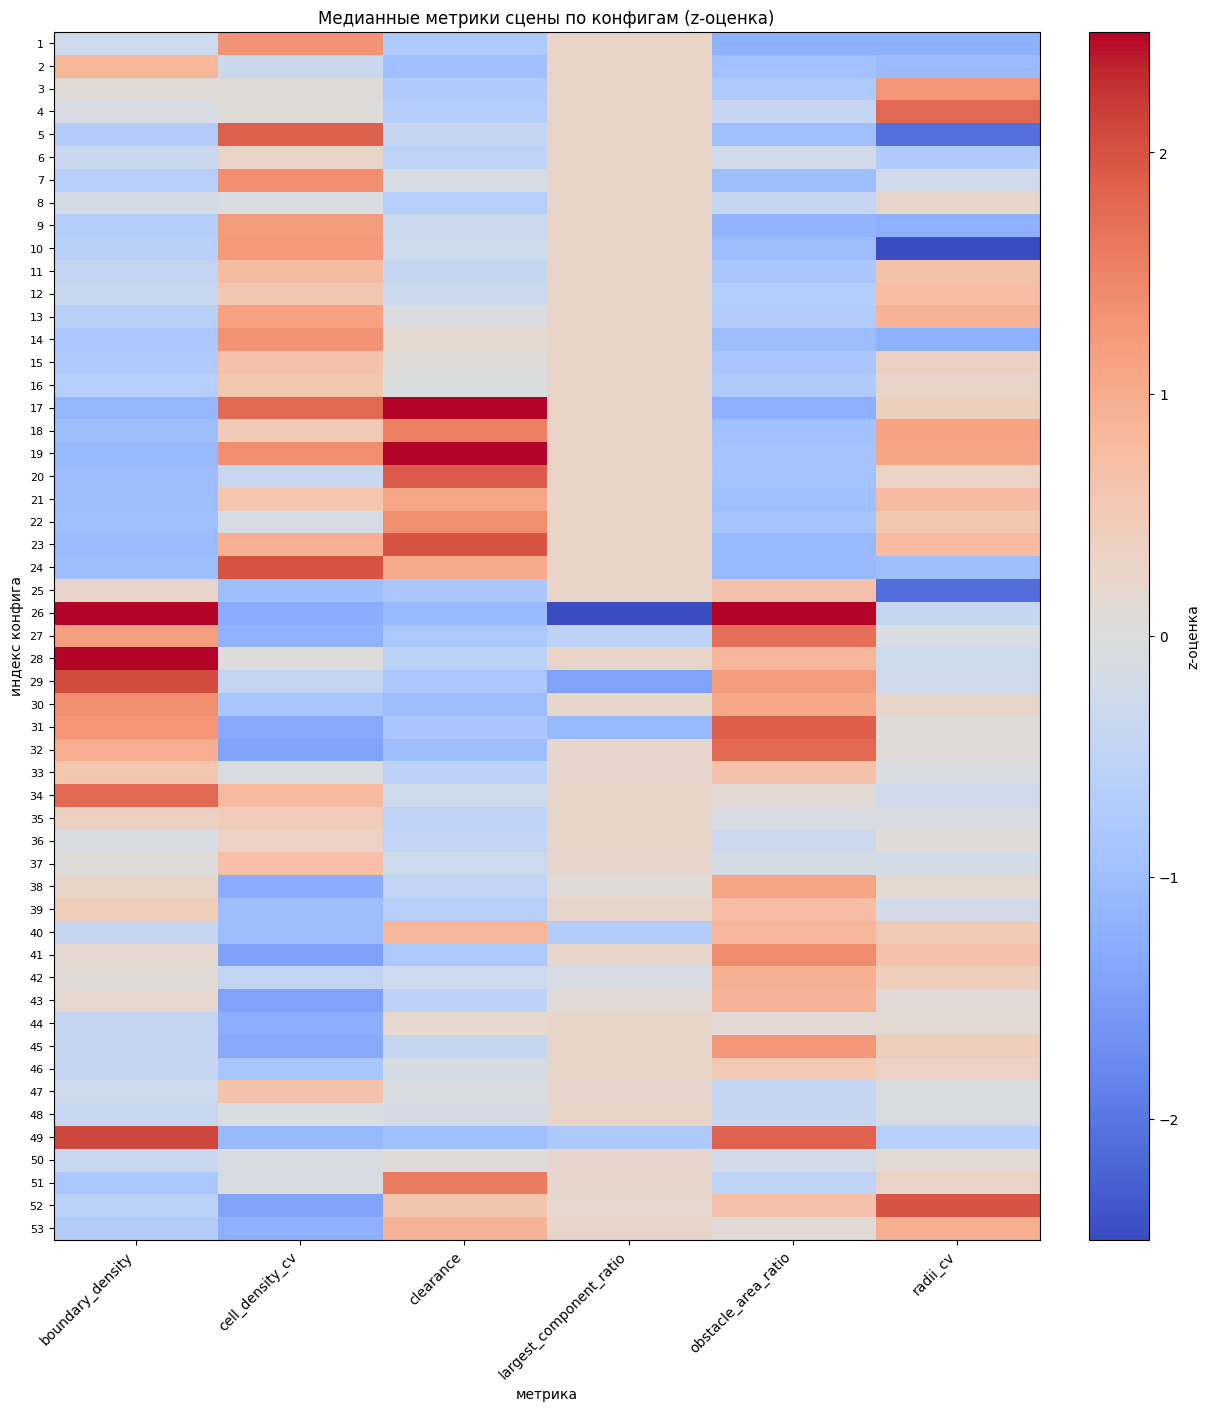

In [87]:
config_metric_median_df = scene_analysis_df.groupby('config_index')[SCENE_METRIC_COLUMNS].median()
config_metric_scaled_df = (
    config_metric_median_df - config_metric_median_df.mean(axis=0)
) / config_metric_median_df.std(axis=0, ddof=0).replace(0.0, 1.0)

fig, ax = plt.subplots(figsize=(12, 14), constrained_layout=True)
image = ax.imshow(config_metric_scaled_df.values, aspect='auto', cmap='coolwarm', vmin=-2.5, vmax=2.5)
ax.set_title('Медианные метрики сцены по конфигам (z-оценка)')
ax.set_xlabel('метрика')
ax.set_ylabel('индекс конфига')
ax.set_xticks(range(len(SCENE_METRIC_COLUMNS)))
ax.set_xticklabels([c.replace('scene_metric_', '') for c in SCENE_METRIC_COLUMNS], rotation=45, ha='right')
ax.set_yticks(range(len(config_metric_scaled_df.index)))
ax.set_yticklabels(config_metric_scaled_df.index.astype(str), fontsize=8)
fig.colorbar(image, ax=ax, label='z-оценка')
config_heatmap_path = OUTPUT_DIR / f'{DATASET_PREFIX}_config_metric_heatmap.png'
fig.savefig(config_heatmap_path, dpi=180, bbox_inches='tight')
print('Saved:', config_heatmap_path)
plt.show()

Конфиги реально различаются между собой, а не повторяют один и тот же сценарий с небольшим шумом. Это важно: поведение алгоритмов оценивается на гетерогенной экспериментальной базе.

## Корреляции метрик среды

Ниже вычисляются попарные корреляции между scene-метриками. Используются:
- `Pearson` — для оценки линейной связи;
- `Spearman` — для оценки монотонной зависимости.

`Spearman` здесь особенно полезен, потому что часть зависимостей на графиках выглядит нелинейной.

In [88]:
pearson_corr_df = scene_analysis_df[SCENE_METRIC_COLUMNS].corr(method='pearson')
spearman_corr_df = scene_analysis_df[SCENE_METRIC_COLUMNS].corr(method='spearman')

correlation_pairs = []
for index, metric_a in enumerate(SCENE_METRIC_COLUMNS):
    for metric_b in SCENE_METRIC_COLUMNS[index + 1:]:
        correlation_pairs.append({
            'metric_a': metric_a,
            'metric_b': metric_b,
            'pearson': pearson_corr_df.loc[metric_a, metric_b],
            'spearman': spearman_corr_df.loc[metric_a, metric_b],
            'abs_pearson': abs(pearson_corr_df.loc[metric_a, metric_b]),
            'abs_spearman': abs(spearman_corr_df.loc[metric_a, metric_b]),
        })

correlation_pairs_df = pd.DataFrame(correlation_pairs).sort_values(
    ['abs_spearman', 'abs_pearson'], ascending=False
).reset_index(drop=True)

pearson_corr_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_pearson_corr.csv'
spearman_corr_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_spearman_corr.csv'
correlation_pairs_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_pairs.csv'

pearson_corr_df.to_csv(pearson_corr_path)
spearman_corr_df.to_csv(spearman_corr_path)
correlation_pairs_df.to_csv(correlation_pairs_path, index=False)

print('Saved:', pearson_corr_path)
print('Saved:', spearman_corr_path)
print('Saved:', correlation_pairs_path)

with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(correlation_pairs_df)

Saved: analysis_outputs\final25_scene_metric_pearson_corr.csv
Saved: analysis_outputs\final25_scene_metric_spearman_corr.csv
Saved: analysis_outputs\final25_scene_metric_correlation_pairs.csv


,metric_a,metric_b,pearson,spearman,abs_pearson,abs_spearman
0,scene_metric_boundary_density,scene_metric_clearance,-0.611133,-0.871264,0.611133,0.871264
1,scene_metric_cell_density_cv,scene_metric_obstacle_area_ratio,-0.811614,-0.843637,0.811614,0.843637
2,scene_metric_largest_component_ratio,scene_metric_obstacle_area_ratio,-0.405835,-0.819817,0.405835,0.819817
3,scene_metric_boundary_density,scene_metric_obstacle_area_ratio,0.739155,0.764198,0.739155,0.764198
4,scene_metric_cell_density_cv,scene_metric_largest_component_ratio,0.221209,0.693079,0.221209,0.693079
5,scene_metric_boundary_density,scene_metric_largest_component_ratio,-0.421748,-0.596861,0.421748,0.596861
6,scene_metric_clearance,scene_metric_obstacle_area_ratio,-0.495489,-0.571394,0.495489,0.571394
7,scene_metric_boundary_density,scene_metric_cell_density_cv,-0.457154,-0.546790,0.457154,0.546790
8,scene_metric_cell_density_cv,scene_metric_clearance,0.384058,0.435132,0.384058,0.435132
9,scene_metric_clearance,scene_metric_largest_component_ratio,0.159946,0.368380,0.159946,0.368380


Saved: analysis_outputs\final25_scene_metric_correlation_heatmaps.png


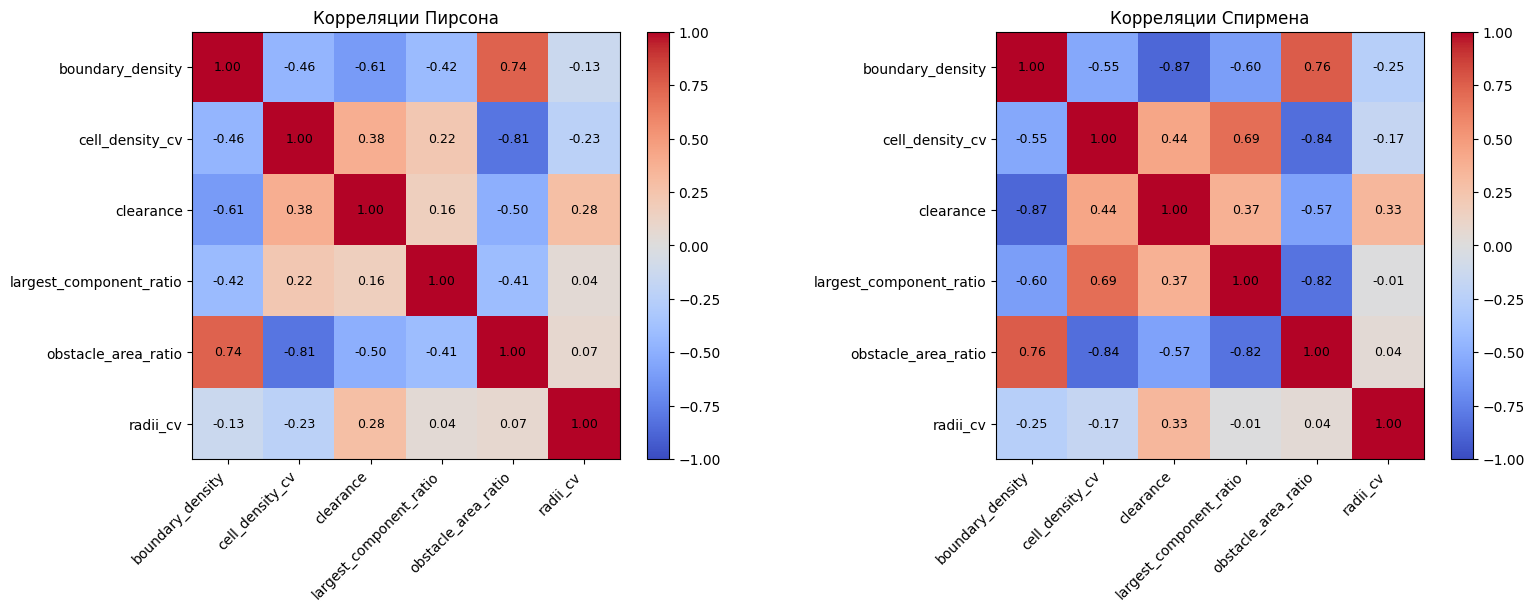

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for ax, corr_df, title in [
    (axes[0], pearson_corr_df, 'Корреляции Пирсона'),
    (axes[1], spearman_corr_df, 'Корреляции Спирмена'),
]:
    image = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(range(len(SCENE_METRIC_COLUMNS)))
    ax.set_yticks(range(len(SCENE_METRIC_COLUMNS)))
    ax.set_xticklabels([c.replace('scene_metric_', '') for c in SCENE_METRIC_COLUMNS], rotation=45, ha='right')
    ax.set_yticklabels([c.replace('scene_metric_', '') for c in SCENE_METRIC_COLUMNS])
    for i in range(len(SCENE_METRIC_COLUMNS)):
        for j in range(len(SCENE_METRIC_COLUMNS)):
            ax.text(j, i, f'{corr_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9, color='black')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

corr_heatmap_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_heatmaps.png'
fig.savefig(corr_heatmap_path, dpi=180, bbox_inches='tight')
print('Saved:', corr_heatmap_path)
plt.show()

Матрицы корреляций показывают, что метрики среды связаны между собой, но не дублируют друг друга полностью. Это ожидаемо: часть из них описывает близкие свойства сцены, например плотность препятствий, связность свободного пространства и ширину проходов.

Наиболее сильные зависимости видны между boundary_density, clearance, obstacle_area_ratio и largest_component_ratio. В целом картина логична: при росте плотности и площади препятствий уменьшается свободное пространство и ухудшается связность среды.

При этом radii_cv заметно слабее связан с остальными метриками. Это полезно, потому что разброс размеров препятствий выступает как более самостоятельная характеристика среды.

Сходство картин для корреляций Пирсона и Спирмена показывает, что основные зависимости устойчивы. В целом набор метрик выглядит достаточно согласованным, но не вырожденным, поэтому его можно использовать для дальнейшего анализа алгоритмов.

In [90]:
strong_pairs_df = correlation_pairs_df.loc[correlation_pairs_df['abs_spearman'] >= 0.7].copy()
moderate_pairs_df = correlation_pairs_df.loc[(correlation_pairs_df['abs_spearman'] >= 0.4) & (correlation_pairs_df['abs_spearman'] < 0.7)].copy()

print('Strong |spearman| >= 0.7 pairs:', len(strong_pairs_df))
display(strong_pairs_df)

print('Moderate 0.4 <= |spearman| < 0.7 pairs:', len(moderate_pairs_df))
display(moderate_pairs_df)

Strong |spearman| >= 0.7 pairs: 4


,metric_a,metric_b,pearson,spearman,abs_pearson,abs_spearman
0,scene_metric_boundary_density,scene_metric_clearance,-0.611133,-0.871264,0.611133,0.871264
1,scene_metric_cell_density_cv,scene_metric_obstacle_area_ratio,-0.811614,-0.843637,0.811614,0.843637
2,scene_metric_largest_component_ratio,scene_metric_obstacle_area_ratio,-0.405835,-0.819817,0.405835,0.819817
3,scene_metric_boundary_density,scene_metric_obstacle_area_ratio,0.739155,0.764198,0.739155,0.764198


Moderate 0.4 <= |spearman| < 0.7 pairs: 5


,metric_a,metric_b,pearson,spearman,abs_pearson,abs_spearman
4,scene_metric_cell_density_cv,scene_metric_largest_component_ratio,0.221209,0.693079,0.221209,0.693079
5,scene_metric_boundary_density,scene_metric_largest_component_ratio,-0.421748,-0.596861,0.421748,0.596861
6,scene_metric_clearance,scene_metric_obstacle_area_ratio,-0.495489,-0.571394,0.495489,0.571394
7,scene_metric_boundary_density,scene_metric_cell_density_cv,-0.457154,-0.546790,0.457154,0.546790
8,scene_metric_cell_density_cv,scene_metric_clearance,0.384058,0.435132,0.384058,0.435132


Выбрали наиболее взаимосвязанные пары параметров, чтобы учесть при дальнейшем анализе. 

## Анализ работы алгоритмов

Для оценки качества работы алгоритмов используются только выполненные запуски (`algorithm_was_executed == True`), а для анализа качества пути — только успешные запуски (`path_found == True`). Строки `NotRun` сохраняются в общем датасете, но не должны влиять на содержательные выводы о работе планировщиков, так как относятся к несгенерированным сценам.

In [ ]:
ALL_RUNS_DF = analysis_run_df.copy()
EXECUTED_RUNS_DF = ALL_RUNS_DF.loc[ALL_RUNS_DF['algorithm_was_executed']].copy()
SUCCESS_RUNS_DF = EXECUTED_RUNS_DF.loc[EXECUTED_RUNS_DF['path_found']].copy()

ALGORITHM_ORDER = sorted(ALL_RUNS_DF['algorithm_id'].dropna().unique())
ALGORITHM_COLORS = {
    'grid_astar': '#4c78a8',
    'grid_dijkstra': '#72b7b2',
    'rrt': '#f58518',
    'visibility_astar': '#e45756',
    'visibility_dijkstra': '#54a24b',
}
STATUS_ORDER = ['Success', 'NoPath', 'NotRun', 'Failed']
SHORT_METRIC_LABELS = {
    'scene_metric_obstacle_area_ratio': 'obstacle_area_ratio',
    'scene_metric_boundary_density': 'boundary_density',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest_component_ratio',
    'scene_metric_cell_density_cv': 'cell_density_cv',
    'scene_metric_radii_cv': 'radii_cv',
    'scene_width': 'scene_width',
    'scene_height': 'scene_height',
    'scene_obstacle_count': 'scene_obstacle_count',
    'scene_direct_distance': 'scene_direct_distance',
}

,algorithm_id,total_slots,Success,NoPath,NotRun,Failed,executed_runs,success_rate_executed,no_path_rate_executed,median_runtime_all_ms,median_runtime_success_ms,p90_runtime_success_ms,mean_runtime_all_ms,median_path_length,median_relative_path_length,p90_relative_path_length
0,visibility_astar,42400,41216,1121,63,0,42337,0.973522,0.026478,109.7786,113.0564,5377.92195,1320.439524,327.316685,1.007930,1.133661
1,visibility_dijkstra,42400,41216,1121,63,0,42337,0.973522,0.026478,112.7131,116.5881,5386.64730,1327.814528,327.316685,1.007930,1.133661
2,grid_astar,42400,40309,2028,63,0,42337,0.952099,0.047901,158.6124,172.3630,5893.30600,2064.703058,356.113246,1.068425,1.232814
3,grid_dijkstra,42400,40309,2028,63,0,42337,0.952099,0.047901,161.4657,174.9076,5930.80356,2074.793473,356.113246,1.068425,1.232814
4,rrt,42400,39234,3103,63,0,42337,0.926707,0.073293,19.7762,15.8554,173.73389,105.085691,332.697240,1.062514,1.298626


Saved: analysis_outputs\final25_algorithm_overview.csv
Saved: analysis_outputs\final25_algorithm_config_success.csv
Saved: analysis_outputs\final25_algorithm_config_runtime.csv
Saved: analysis_outputs\final25_algorithm_config_quality.csv


In [ ]:
status_counts_df = ALL_RUNS_DF.groupby(['algorithm_id', 'algorithm_status']).size().unstack(fill_value=0)
status_counts_df = status_counts_df.reindex(index=ALGORITHM_ORDER, columns=STATUS_ORDER, fill_value=0)

algorithm_overview_df = pd.DataFrame(index=ALGORITHM_ORDER)
algorithm_overview_df['total_slots'] = ALL_RUNS_DF.groupby('algorithm_id').size().reindex(ALGORITHM_ORDER)
algorithm_overview_df = algorithm_overview_df.join(status_counts_df)
algorithm_overview_df['executed_runs'] = algorithm_overview_df[['Success', 'NoPath', 'Failed']].sum(axis=1)
algorithm_overview_df['success_rate_executed'] = algorithm_overview_df['Success'] / algorithm_overview_df['executed_runs']
algorithm_overview_df['no_path_rate_executed'] = algorithm_overview_df['NoPath'] / algorithm_overview_df['executed_runs']
algorithm_overview_df['median_runtime_all_ms'] = EXECUTED_RUNS_DF.groupby('algorithm_id')['runtime_ms'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_runtime_success_ms'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['runtime_ms'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['p90_runtime_success_ms'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['runtime_ms'].quantile(0.9).reindex(ALGORITHM_ORDER)
algorithm_overview_df['mean_runtime_all_ms'] = EXECUTED_RUNS_DF.groupby('algorithm_id')['runtime_ms'].mean().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['path_length'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_relative_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['relative_path_length'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['p90_relative_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['relative_path_length'].quantile(0.9).reindex(ALGORITHM_ORDER)
algorithm_overview_df = algorithm_overview_df.sort_values(['success_rate_executed', 'median_runtime_success_ms'], ascending=[False, True])

In [ ]:
config_success_df = EXECUTED_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    success_rate=('path_found', 'mean'),
    executed_runs=('algorithm_id', 'size'),
).reset_index()

config_runtime_df = SUCCESS_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    median_runtime_success_ms=('runtime_ms', 'median'),
    success_count=('algorithm_id', 'size'),
).reset_index()

config_quality_df = SUCCESS_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    median_relative_path_length=('relative_path_length', 'median'),
    median_path_length=('path_length', 'median'),
).reset_index()

config_runtime_winners_df = config_runtime_df.loc[config_runtime_df.groupby('config_index')['median_runtime_success_ms'].idxmin()].copy()
config_quality_winners_df = config_quality_df.loc[config_quality_df.groupby('config_index')['median_relative_path_length'].idxmin()].copy()

algorithm_overview_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_overview.csv'
config_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_success.csv'
config_runtime_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_runtime.csv'
config_quality_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_quality.csv'
algorithm_overview_df.reset_index(names='algorithm_id').to_csv(algorithm_overview_path, index=False)
config_success_df.to_csv(config_success_path, index=False)
config_runtime_df.to_csv(config_runtime_path, index=False)
config_quality_df.to_csv(config_quality_path, index=False)

with pd.option_context('display.max_columns', None, 'display.width', 2400):
    display(algorithm_overview_df.reset_index(names='algorithm_id'))

print('Saved:', algorithm_overview_path)
print('Saved:', config_success_path)
print('Saved:', config_runtime_path)
print('Saved:', config_quality_path)

In [92]:
best_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmax()
fastest_success_algorithm = algorithm_overview_df['median_runtime_success_ms'].idxmin()
best_quality_algorithm = algorithm_overview_df['median_relative_path_length'].idxmin()
weakest_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmin()

print(f"Лучшая успешность: {best_success_algorithm} ({algorithm_overview_df.loc[best_success_algorithm, 'success_rate_executed']:.2%})")
print(f"Наименьшая успешность: {weakest_success_algorithm} ({algorithm_overview_df.loc[weakest_success_algorithm, 'success_rate_executed']:.2%})")
print(f"Лучшее медианное время успешного запуска: {fastest_success_algorithm} ({algorithm_overview_df.loc[fastest_success_algorithm, 'median_runtime_success_ms']:.2f} мс)")
print(f"Лучшее медианное качество пути: {best_quality_algorithm} ({algorithm_overview_df.loc[best_quality_algorithm, 'median_relative_path_length']:.4f})")

print('Победители по конфигам по медианному времени успешного запуска:')
print(config_runtime_winners_df['algorithm_id'].value_counts().to_string())

print('Победители по конфигам по медианному качеству пути:')
print(config_quality_winners_df['algorithm_id'].value_counts().to_string())

Лучшая успешность: visibility_astar (97.35%)
Наименьшая успешность: rrt (92.67%)
Лучшее медианное время успешного запуска: rrt (15.86 мс)
Лучшее медианное качество пути: visibility_astar (1.0079)
Победители по конфигам по медианному времени успешного запуска:
rrt                    50
visibility_astar        1
grid_dijkstra           1
visibility_dijkstra     1
Победители по конфигам по медианному качеству пути:
visibility_astar    53


Saved: analysis_outputs\final25_algorithm_overview.png


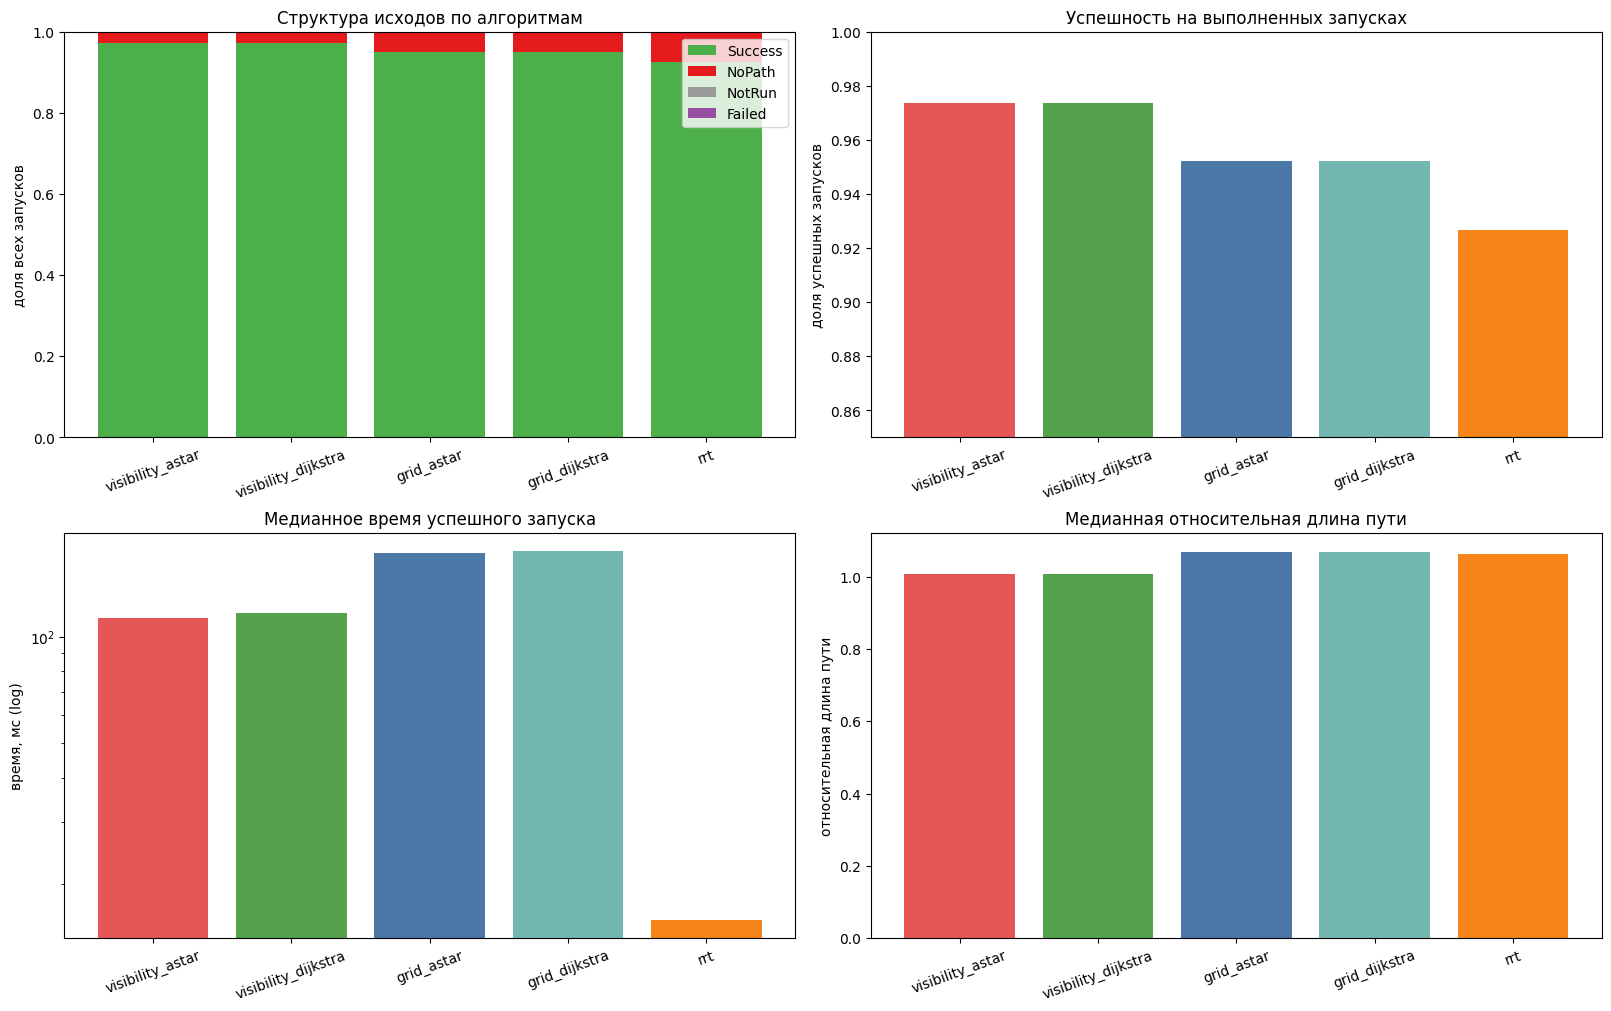

In [93]:
plot_order = algorithm_overview_df.index.tolist()
status_share_df = status_counts_df.loc[plot_order].div(status_counts_df.loc[plot_order].sum(axis=1), axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

bottom = np.zeros(len(plot_order))
for status, color in [('Success', '#4daf4a'), ('NoPath', '#e41a1c'), ('NotRun', '#999999'), ('Failed', '#984ea3')]:
    values = status_share_df[status].values
    axes[0, 0].bar(plot_order, values, bottom=bottom, color=color, label=status)
    bottom += values
axes[0, 0].set_title('Структура исходов по алгоритмам')
axes[0, 0].set_ylabel('доля всех запусков')
axes[0, 0].legend(loc='upper right')
axes[0, 0].tick_params(axis='x', rotation=20)

success_values = algorithm_overview_df.loc[plot_order, 'success_rate_executed']
axes[0, 1].bar(plot_order, success_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[0, 1].set_title('Успешность на выполненных запусках')
axes[0, 1].set_ylabel('доля успешных запусков')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].tick_params(axis='x', rotation=20)

runtime_values = algorithm_overview_df.loc[plot_order, 'median_runtime_success_ms']
axes[1, 0].bar(plot_order, runtime_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Медианное время успешного запуска')
axes[1, 0].set_ylabel('время, мс (log)')
axes[1, 0].tick_params(axis='x', rotation=20)

quality_values = algorithm_overview_df.loc[plot_order, 'median_relative_path_length']
axes[1, 1].bar(plot_order, quality_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[1, 1].set_title('Медианная относительная длина пути')
axes[1, 1].set_ylabel('относительная длина пути')
axes[1, 1].tick_params(axis='x', rotation=20)

overview_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_overview.png'
fig.savefig(overview_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', overview_figure_path)
plt.show()

На этом уровне уже хорошо видно главную картину: visibility-методы лидируют по успешности и качеству, RRT лидирует по времени, а grid-подходы оказываются компромиссным, но более дорогим по времени классом.

Saved: analysis_outputs\final25_algorithm_distributions_tradeoff.png


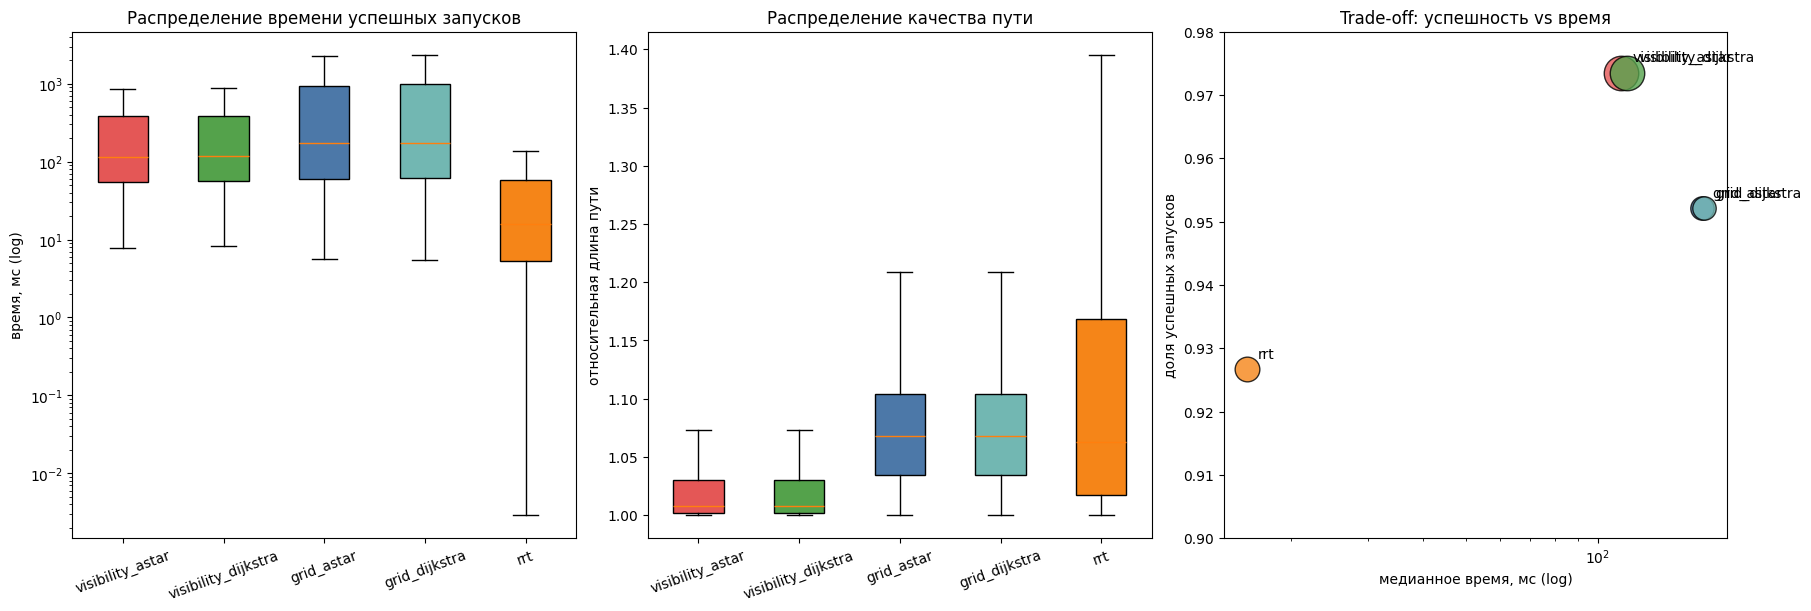

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

runtime_series = [SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'runtime_ms'].values for algorithm_id in plot_order]
runtime_box = axes[0].boxplot(runtime_series, tick_labels=plot_order, showfliers=False, patch_artist=True)
for patch, algorithm_id in zip(runtime_box['boxes'], plot_order):
    patch.set_facecolor(ALGORITHM_COLORS[algorithm_id])
axes[0].set_yscale('log')
axes[0].set_title('Распределение времени успешных запусков')
axes[0].set_ylabel('время, мс (log)')
axes[0].tick_params(axis='x', rotation=20)

quality_series = [SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'relative_path_length'].values for algorithm_id in plot_order]
quality_box = axes[1].boxplot(quality_series, tick_labels=plot_order, showfliers=False, patch_artist=True)
for patch, algorithm_id in zip(quality_box['boxes'], plot_order):
    patch.set_facecolor(ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('Распределение качества пути')
axes[1].set_ylabel('относительная длина пути')
axes[1].tick_params(axis='x', rotation=20)

tradeoff_df = algorithm_overview_df.loc[plot_order].reset_index(names='algorithm_id')
for _, row in tradeoff_df.iterrows():
    marker_size = max(120.0, 5500.0 * (1.12 - min(row['median_relative_path_length'], 1.11)))
    axes[2].scatter(
        row['median_runtime_success_ms'],
        row['success_rate_executed'],
        s=marker_size,
        color=ALGORITHM_COLORS[row['algorithm_id']],
        alpha=0.8,
        edgecolors='black',
    )
    axes[2].annotate(row['algorithm_id'], (row['median_runtime_success_ms'], row['success_rate_executed']), xytext=(8, 8), textcoords='offset points')
axes[2].set_xscale('log')
axes[2].set_title('Trade-off: успешность vs время')
axes[2].set_xlabel('медианное время, мс (log)')
axes[2].set_ylabel('доля успешных запусков')
axes[2].set_ylim(0.9, 0.98)

distribution_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_distributions_tradeoff.png'
fig.savefig(distribution_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', distribution_figure_path)
plt.show()

Медианы не рассказывают всю историю. По этим распределениям видно, насколько устойчиво алгоритмы удерживают своё преимущество по всему массиву сцен, а не только в среднем.

Saved: analysis_outputs\final25_algorithm_config_heatmaps.png


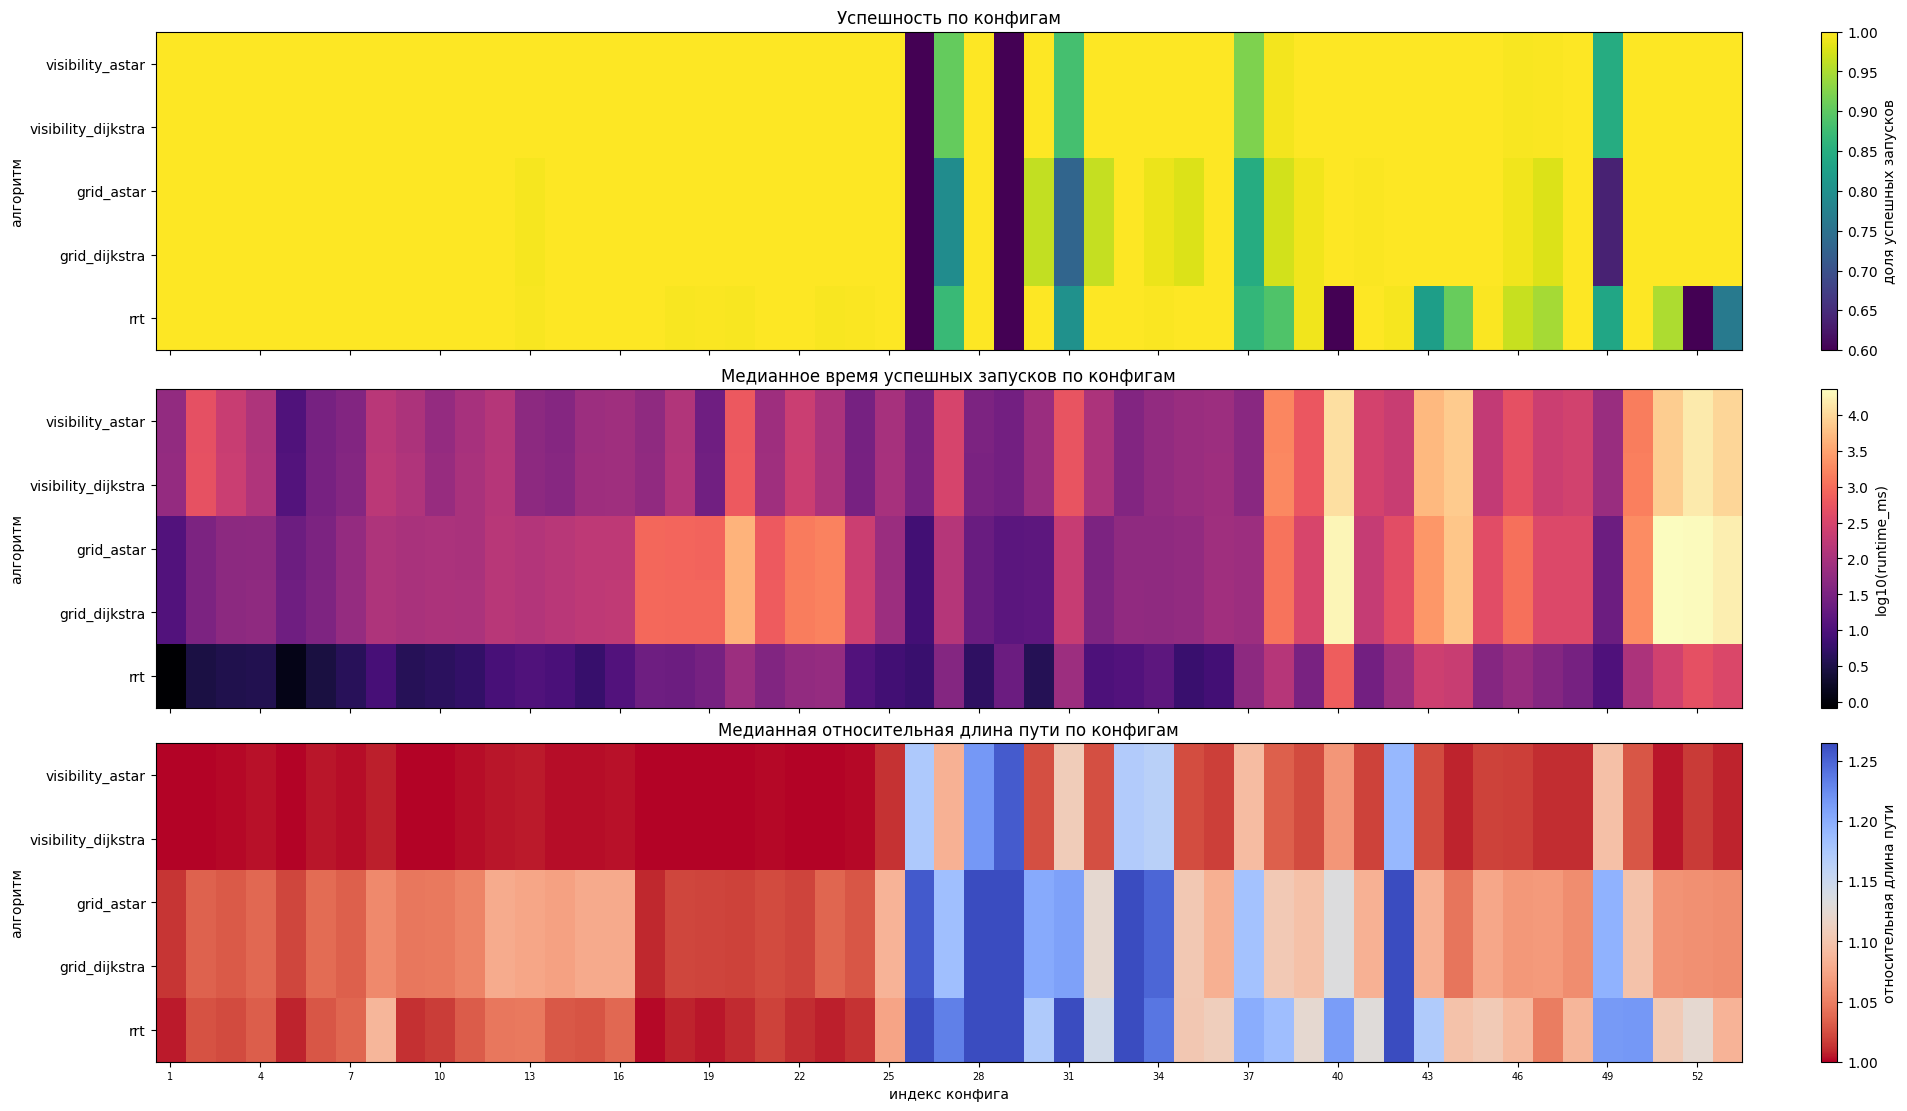

In [95]:
success_heatmap_df = config_success_df.pivot(index='algorithm_id', columns='config_index', values='success_rate').reindex(plot_order)
runtime_heatmap_df = config_runtime_df.pivot(index='algorithm_id', columns='config_index', values='median_runtime_success_ms').reindex(plot_order)
quality_heatmap_df = config_quality_df.pivot(index='algorithm_id', columns='config_index', values='median_relative_path_length').reindex(plot_order)

fig, axes = plt.subplots(3, 1, figsize=(19, 11), constrained_layout=True, sharex=True)
xtick_positions = list(range(0, len(success_heatmap_df.columns), 3))
xtick_labels = success_heatmap_df.columns.astype(int).tolist()[::3]

image = axes[0].imshow(success_heatmap_df.values, aspect='auto', cmap='viridis', vmin=0.6, vmax=1.0)
axes[0].set_title('Успешность по конфигам')
axes[0].set_ylabel('алгоритм')
axes[0].set_yticks(range(len(plot_order)))
axes[0].set_yticklabels(plot_order)
fig.colorbar(image, ax=axes[0], label='доля успешных запусков')

runtime_log_values = np.log10(runtime_heatmap_df.values)
image = axes[1].imshow(runtime_log_values, aspect='auto', cmap='magma')
axes[1].set_title('Медианное время успешных запусков по конфигам')
axes[1].set_ylabel('алгоритм')
axes[1].set_yticks(range(len(plot_order)))
axes[1].set_yticklabels(plot_order)
fig.colorbar(image, ax=axes[1], label='log10(runtime_ms)')

quality_limit = np.nanpercentile(quality_heatmap_df.values, 95)
image = axes[2].imshow(quality_heatmap_df.values, aspect='auto', cmap='coolwarm_r', vmin=1.0, vmax=quality_limit)
axes[2].set_title('Медианная относительная длина пути по конфигам')
axes[2].set_ylabel('алгоритм')
axes[2].set_xlabel('индекс конфига')
axes[2].set_yticks(range(len(plot_order)))
axes[2].set_yticklabels(plot_order)
axes[2].set_xticks(xtick_positions)
axes[2].set_xticklabels(xtick_labels, rotation=0, fontsize=7)
fig.colorbar(image, ax=axes[2], label='относительная длина пути')

config_heatmap_algo_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_heatmaps.png'
fig.savefig(config_heatmap_algo_path, dpi=180, bbox_inches='tight')
print('Saved:', config_heatmap_algo_path)
plt.show()

Различия между алгоритмами сильно зависят от семейства конфигов. Особенно важно, что на тяжёлых конфигурациях расслоение между методами становится намного более выраженным, чем на простых сценах.

Saved: analysis_outputs\final25_algorithm_runtime_pairwise.csv
Saved: analysis_outputs\final25_algorithm_quality_pairwise.csv
Saved: analysis_outputs\final25_algorithm_pairwise_dominance.png


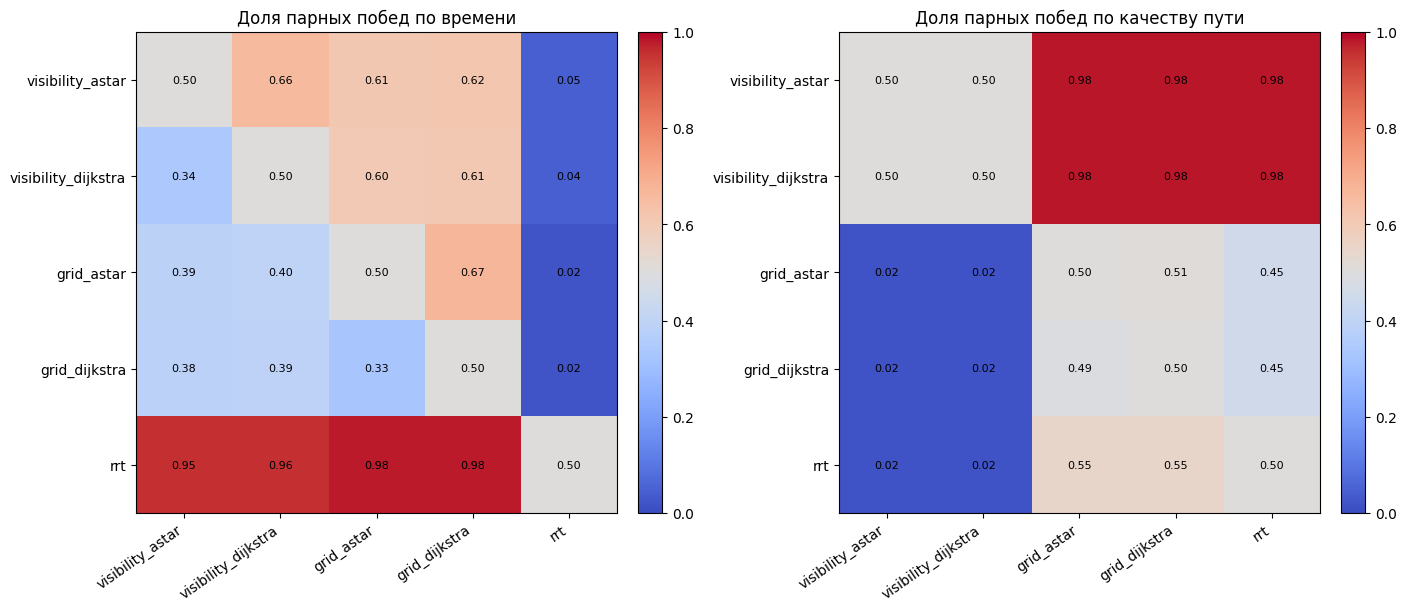

In [ ]:
def build_tie_aware_share_matrix(pivot_df):
    algorithms = list(pivot_df.columns)
    share_matrix = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    support_matrix = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    for algorithm_a in algorithms:
        for algorithm_b in algorithms:
            common = pivot_df[[algorithm_a, algorithm_b]].dropna()
            support_matrix.loc[algorithm_a, algorithm_b] = len(common)
            if len(common) == 0:
                share_matrix.loc[algorithm_a, algorithm_b] = np.nan
            elif algorithm_a == algorithm_b:
                share_matrix.loc[algorithm_a, algorithm_b] = 0.5
            else:
                better_share = (common[algorithm_a] < common[algorithm_b]).mean()
                tie_share = (common[algorithm_a] == common[algorithm_b]).mean()
                share_matrix.loc[algorithm_a, algorithm_b] = better_share + 0.5 * tie_share
    return share_matrix.astype(float), support_matrix.astype(int)

In [ ]:
runtime_pivot_df = SUCCESS_RUNS_DF.pivot_table(index=['config_index', 'scene_id'], columns='algorithm_id', values='runtime_ms')
quality_pivot_df = SUCCESS_RUNS_DF.pivot_table(index=['config_index', 'scene_id'], columns='algorithm_id', values='relative_path_length')
runtime_pairwise_df, runtime_support_df = build_tie_aware_share_matrix(runtime_pivot_df)
quality_pairwise_df, quality_support_df = build_tie_aware_share_matrix(quality_pivot_df)

runtime_pairwise_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_pairwise.csv'
quality_pairwise_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_pairwise.csv'
runtime_pairwise_df.to_csv(runtime_pairwise_path)
quality_pairwise_df.to_csv(quality_pairwise_path)

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, matrix_df, title in [
    (axes[0], runtime_pairwise_df.reindex(index=plot_order, columns=plot_order), 'Доля парных побед по времени'),
    (axes[1], quality_pairwise_df.reindex(index=plot_order, columns=plot_order), 'Доля парных побед по качеству пути'),
]:
    image = ax.imshow(matrix_df.values, cmap='coolwarm', vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(range(len(plot_order)))
    ax.set_yticks(range(len(plot_order)))
    ax.set_xticklabels(plot_order, rotation=35, ha='right')
    ax.set_yticklabels(plot_order)
    for i in range(len(plot_order)):
        for j in range(len(plot_order)):
            ax.text(j, i, f'{matrix_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

pairwise_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_pairwise_dominance.png'
fig.savefig(pairwise_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_pairwise_path)
print('Saved:', quality_pairwise_path)
print('Saved:', pairwise_figure_path)
plt.show()

Этот анализ отвечает на более сильный вопрос, чем сравнение средних: насколько часто один алгоритм реально оказывается лучше другого на одних и тех же сценах.

Saved: analysis_outputs\final25_algorithm_metric_correlations.csv
Saved: analysis_outputs\final25_algorithm_metric_correlation_heatmaps.png


,algorithm_id,metric,success_spearman,runtime_spearman,quality_spearman
0,rrt,scene_metric_largest_component_ratio,0.365617,-0.508582,-0.662441
1,grid_dijkstra,scene_metric_largest_component_ratio,0.345807,-0.078329,-0.637072
2,grid_astar,scene_metric_largest_component_ratio,0.345807,-0.082241,-0.637072
3,grid_dijkstra,scene_metric_boundary_density,-0.322360,-0.556202,0.684438
4,grid_astar,scene_metric_boundary_density,-0.322360,-0.552208,0.684438
5,grid_dijkstra,scene_metric_obstacle_area_ratio,-0.311323,-0.080802,0.722728
6,grid_astar,scene_metric_obstacle_area_ratio,-0.311323,-0.076881,0.722728
7,rrt,scene_metric_obstacle_area_ratio,-0.284669,0.392838,0.737049
8,rrt,scene_metric_cell_density_cv,0.282766,-0.504150,-0.548810
9,grid_dijkstra,scene_metric_clearance,0.278003,0.720611,-0.434125


,algorithm_id,metric,success_spearman,runtime_spearman,quality_spearman
0,grid_dijkstra,scene_direct_distance,0.237009,0.973436,-0.205626
1,grid_astar,scene_direct_distance,0.237009,0.973229,-0.205626
2,visibility_astar,scene_obstacle_count,0.072365,0.956537,0.322860
3,visibility_dijkstra,scene_obstacle_count,0.072365,0.952961,0.322860
4,grid_dijkstra,scene_width,0.225085,0.928407,-0.180584
5,grid_astar,scene_width,0.225085,0.928171,-0.180584
6,grid_dijkstra,scene_height,0.234240,0.908503,-0.157875
7,grid_astar,scene_height,0.234240,0.908202,-0.157875
8,grid_dijkstra,scene_metric_clearance,0.278003,0.720611,-0.434125
9,grid_astar,scene_metric_clearance,0.278003,0.718561,-0.434125


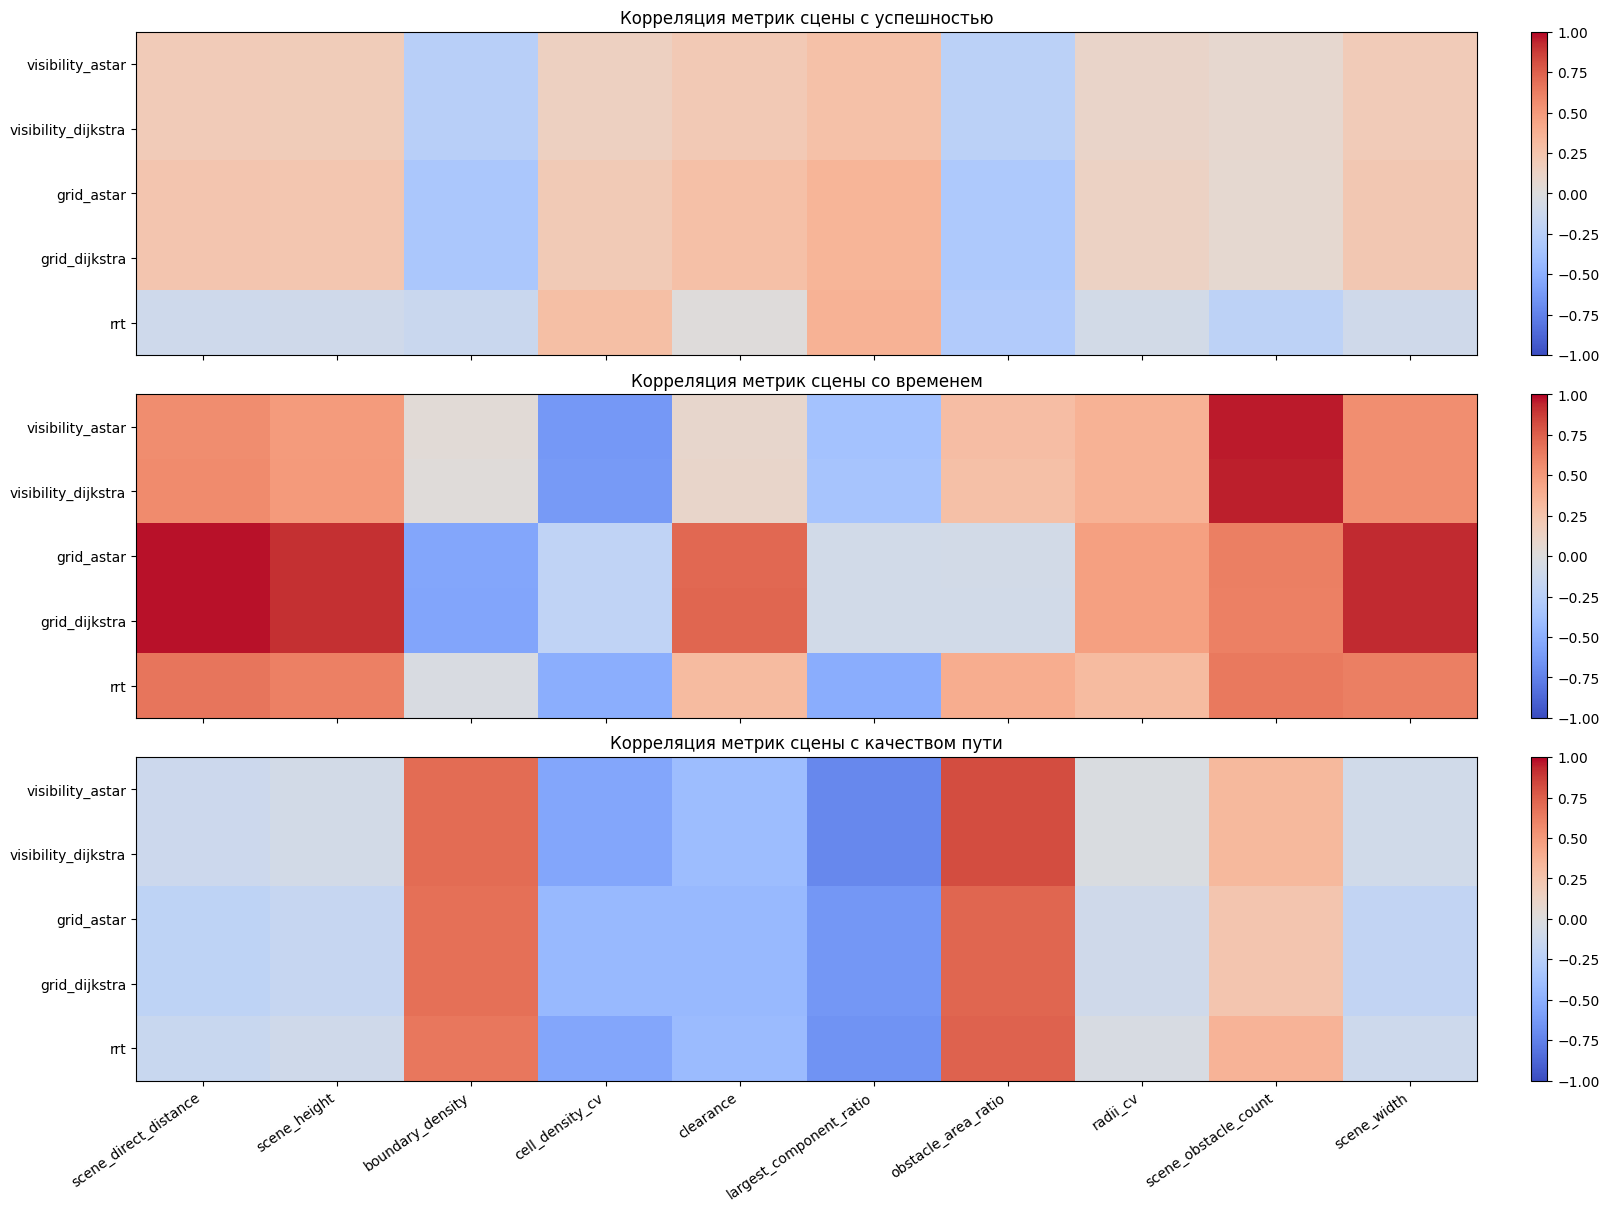

In [97]:
ALGO_CORRELATION_METRICS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_width',
    'scene_height',
    'scene_obstacle_count',
    'scene_direct_distance',
]

correlation_rows = []
for algorithm_id, algorithm_df in EXECUTED_RUNS_DF.groupby('algorithm_id'):
    for metric in ALGO_CORRELATION_METRICS:
        success_corr = algorithm_df[[metric, 'path_found']].corr(method='spearman').iloc[0, 1]
        runtime_corr = algorithm_df.loc[algorithm_df['runtime_ms'] >= 0, [metric, 'runtime_ms']].corr(method='spearman').iloc[0, 1]
        quality_corr = algorithm_df.loc[algorithm_df['path_found'], [metric, 'relative_path_length']].corr(method='spearman').iloc[0, 1]
        correlation_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'success_spearman': success_corr,
            'runtime_spearman': runtime_corr,
            'quality_spearman': quality_corr,
        })

algorithm_metric_correlations_df = pd.DataFrame(correlation_rows)
algorithm_metric_correlations_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_metric_correlations.csv'
algorithm_metric_correlations_df.to_csv(algorithm_metric_correlations_path, index=False)

success_corr_heatmap_df = algorithm_metric_correlations_df.pivot(index='algorithm_id', columns='metric', values='success_spearman').reindex(plot_order)
runtime_corr_heatmap_df = algorithm_metric_correlations_df.pivot(index='algorithm_id', columns='metric', values='runtime_spearman').reindex(plot_order)
quality_corr_heatmap_df = algorithm_metric_correlations_df.pivot(index='algorithm_id', columns='metric', values='quality_spearman').reindex(plot_order)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True, sharex=True)
for ax, corr_df, title in [
    (axes[0], success_corr_heatmap_df, 'Корреляция метрик сцены с успешностью'),
    (axes[1], runtime_corr_heatmap_df, 'Корреляция метрик сцены со временем'),
    (axes[2], quality_corr_heatmap_df, 'Корреляция метрик сцены с качеством пути'),
]:
    plot_df = corr_df.rename(columns=SHORT_METRIC_LABELS)
    image = ax.imshow(plot_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
    ax.set_title(title)
    ax.set_yticks(range(len(plot_df.index)))
    ax.set_yticklabels(plot_df.index)
    ax.set_xticks(range(len(plot_df.columns)))
    ax.set_xticklabels(plot_df.columns, rotation=35, ha='right')
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

correlation_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_metric_correlation_heatmaps.png'
fig.savefig(correlation_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', algorithm_metric_correlations_path)
print('Saved:', correlation_figure_path)

top_success_links_df = algorithm_metric_correlations_df.reindex(
    algorithm_metric_correlations_df['success_spearman'].abs().sort_values(ascending=False).index
).reset_index(drop=True)
top_runtime_links_df = algorithm_metric_correlations_df.reindex(
    algorithm_metric_correlations_df['runtime_spearman'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

display(top_success_links_df.head(15))
display(top_runtime_links_df.head(15))
plt.show()

Здесь уже можно говорить не только о различиях между алгоритмами, но и о том, *почему* эти различия возникают. Метрики среды действительно помогают объяснить успешность, время работы и качество пути каждого семейства методов.

Saved: analysis_outputs\final25_algorithm_metric_profiles.csv
Saved: analysis_outputs\final25_algorithm_metric_profiles.png


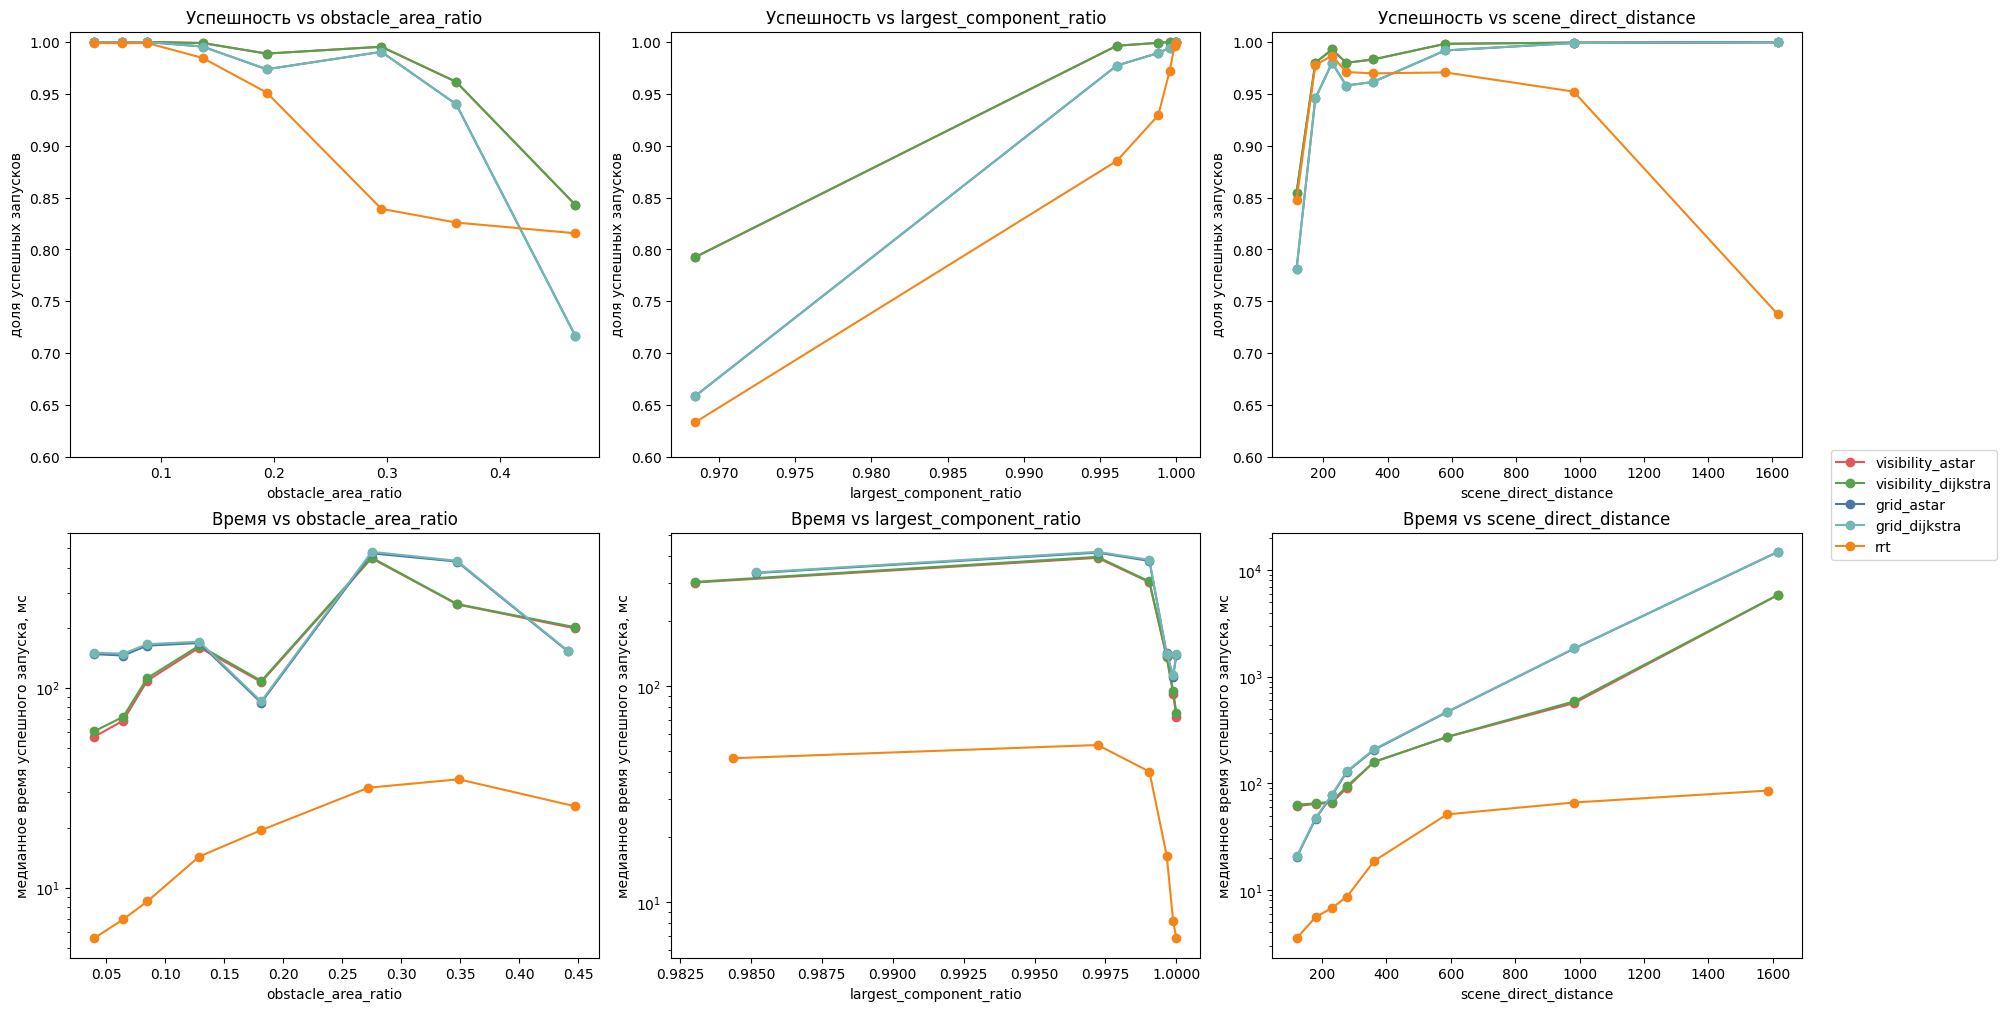

In [98]:
PROFILE_METRICS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_largest_component_ratio',
    'scene_direct_distance',
]

profile_frames = []
for metric in PROFILE_METRICS:
    success_temp_df = EXECUTED_RUNS_DF[[metric, 'algorithm_id', 'path_found']].copy()
    success_temp_df['metric_bin'] = pd.qcut(success_temp_df[metric], q=8, duplicates='drop')
    success_profile_df = success_temp_df.groupby(['algorithm_id', 'metric_bin']).agg(
        metric_value=(metric, 'median'),
        success_rate=('path_found', 'mean'),
        sample_count=('path_found', 'size'),
    ).reset_index()
    success_profile_df['profile_type'] = 'success_rate'
    success_profile_df['metric'] = metric
    profile_frames.append(success_profile_df)

    runtime_temp_df = SUCCESS_RUNS_DF[[metric, 'algorithm_id', 'runtime_ms']].copy()
    runtime_temp_df['metric_bin'] = pd.qcut(runtime_temp_df[metric], q=8, duplicates='drop')
    runtime_profile_df = runtime_temp_df.groupby(['algorithm_id', 'metric_bin']).agg(
        metric_value=(metric, 'median'),
        median_runtime_ms=('runtime_ms', 'median'),
        sample_count=('runtime_ms', 'size'),
    ).reset_index()
    runtime_profile_df['profile_type'] = 'median_runtime_ms'
    runtime_profile_df['metric'] = metric
    profile_frames.append(runtime_profile_df)

algorithm_profiles_df = pd.concat(profile_frames, ignore_index=True)
algorithm_profiles_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_metric_profiles.csv'
algorithm_profiles_df.to_csv(algorithm_profiles_path, index=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for axis_index, metric in enumerate(PROFILE_METRICS):
    ax = axes[0, axis_index]
    metric_df = algorithm_profiles_df.loc[(algorithm_profiles_df['metric'] == metric) & (algorithm_profiles_df['profile_type'] == 'success_rate')]
    for algorithm_id in plot_order:
        line_df = metric_df.loc[metric_df['algorithm_id'] == algorithm_id].sort_values('metric_value')
        ax.plot(line_df['metric_value'], line_df['success_rate'], marker='o', label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
    ax.set_title(f'Успешность vs {SHORT_METRIC_LABELS[metric]}')
    ax.set_xlabel(SHORT_METRIC_LABELS[metric])
    ax.set_ylabel('доля успешных запусков')
    ax.set_ylim(0.6, 1.01)

for axis_index, metric in enumerate(PROFILE_METRICS):
    ax = axes[1, axis_index]
    metric_df = algorithm_profiles_df.loc[(algorithm_profiles_df['metric'] == metric) & (algorithm_profiles_df['profile_type'] == 'median_runtime_ms')]
    for algorithm_id in plot_order:
        line_df = metric_df.loc[metric_df['algorithm_id'] == algorithm_id].sort_values('metric_value')
        ax.plot(line_df['metric_value'], line_df['median_runtime_ms'], marker='o', label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
    ax.set_title(f'Время vs {SHORT_METRIC_LABELS[metric]}')
    ax.set_xlabel(SHORT_METRIC_LABELS[metric])
    ax.set_ylabel('медианное время успешного запуска, мс')
    ax.set_yscale('log')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
profile_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_metric_profiles.png'
fig.savefig(profile_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', algorithm_profiles_path)
print('Saved:', profile_figure_path)
plt.show()

### Интерпретация trade-off

Этот блок следует читать как академическое сравнение трёх критериев:

- `success_rate_executed` — насколько алгоритм устойчиво находит путь;
- `median_runtime_success_ms` — сколько обычно стоит успешное решение;
- `median_relative_path_length` — насколько качественный маршрут возвращает алгоритм относительно прямой линии.

Ожидаемо между этими критериями возникает конфликт: более быстрый алгоритм может быть менее устойчивым или давать менее качественный путь, а более качественный — требовать больше времени.

## Дополнительные визуализации и итоговая интерпретация

В этой части добавлены более наглядные визуальные представления результатов: линейные профили по конфигам, круговые диаграммы исходов и победителей, ECDF-кривые, scatter-графики и итоговый текстовый вывод.

Saved: analysis_outputs\final25_algorithm_config_lines.png


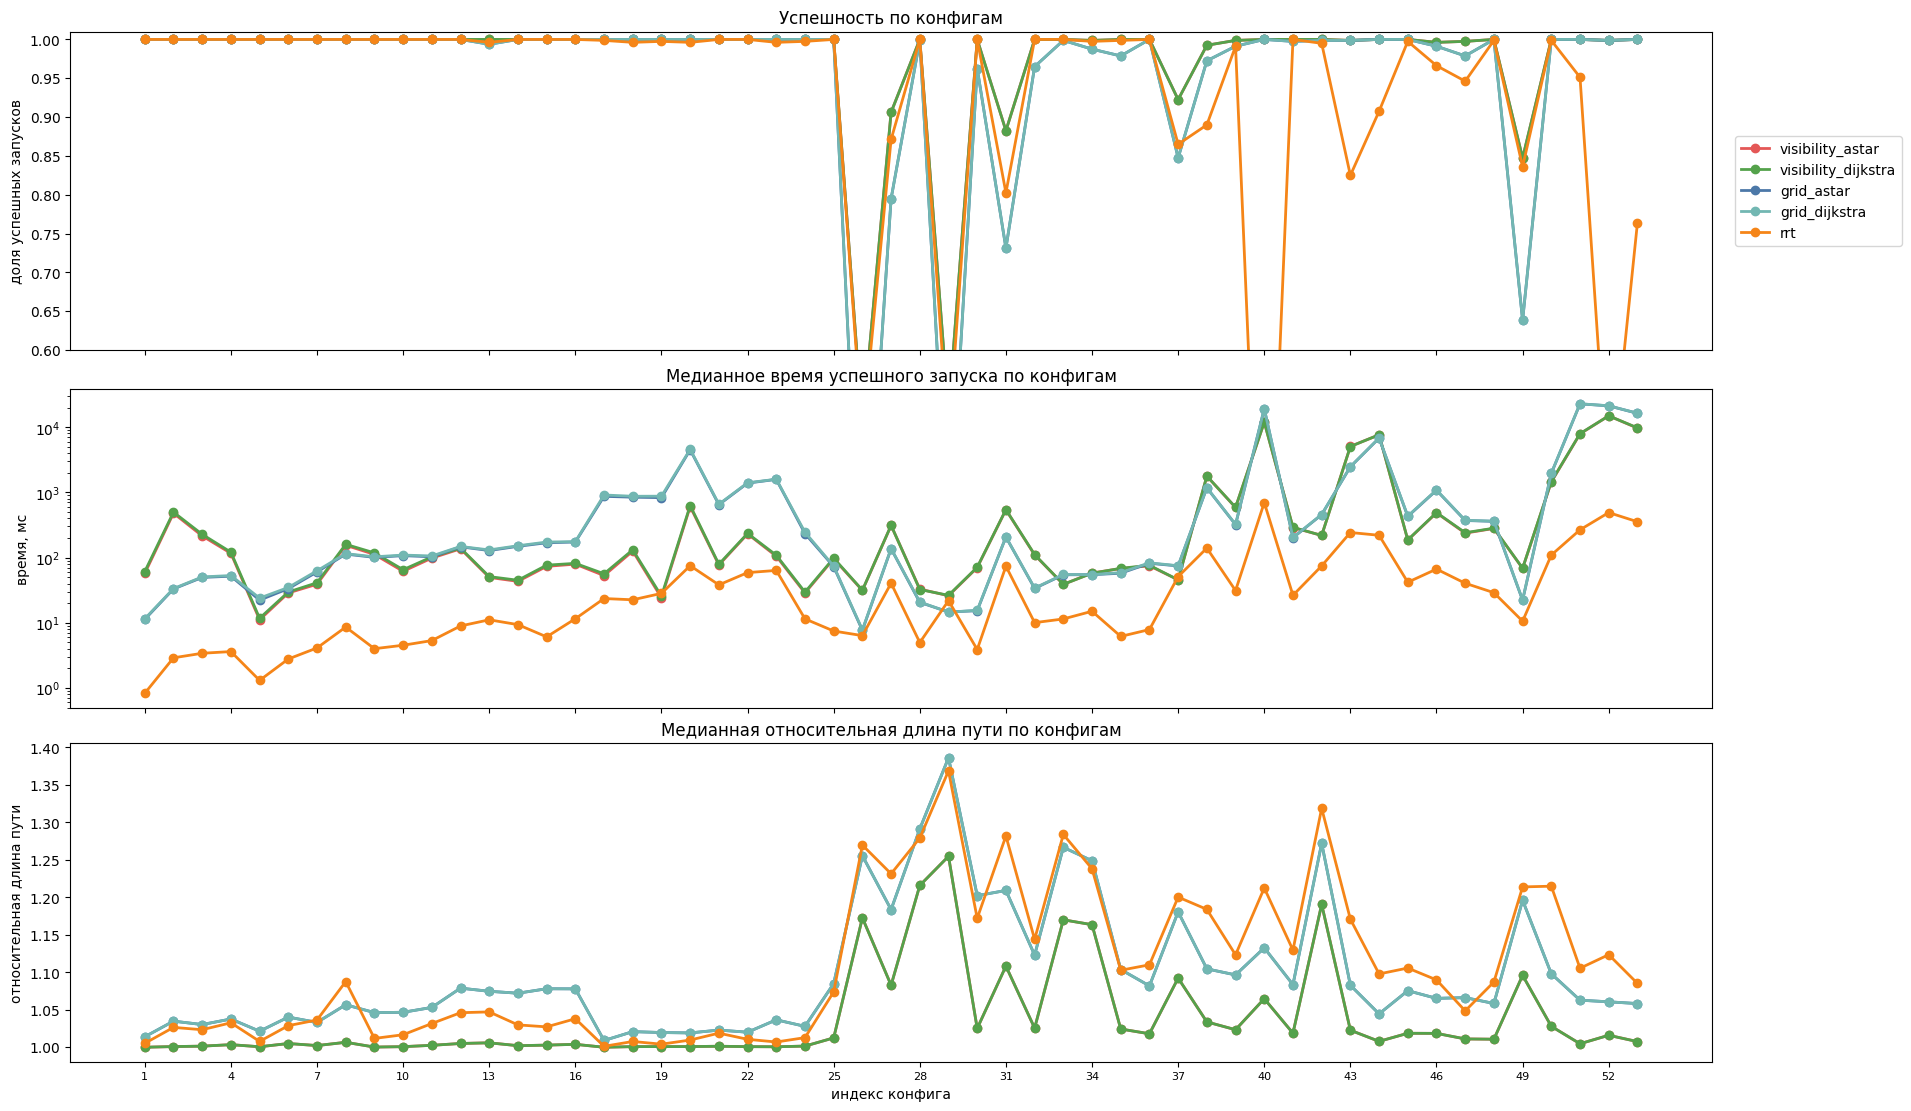

In [99]:
fig, axes = plt.subplots(3, 1, figsize=(19, 11), constrained_layout=True, sharex=True)

for algorithm_id in plot_order:
    algo_success_df = config_success_df.loc[config_success_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[0].plot(algo_success_df['config_index'], algo_success_df['success_rate'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[0].set_title('Успешность по конфигам')
axes[0].set_ylabel('доля успешных запусков')
axes[0].set_ylim(0.6, 1.01)
axes[0].legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

for algorithm_id in plot_order:
    algo_runtime_df = config_runtime_df.loc[config_runtime_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[1].plot(algo_runtime_df['config_index'], algo_runtime_df['median_runtime_success_ms'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('Медианное время успешного запуска по конфигам')
axes[1].set_ylabel('время, мс')
axes[1].set_yscale('log')

for algorithm_id in plot_order:
    algo_quality_df = config_quality_df.loc[config_quality_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[2].plot(algo_quality_df['config_index'], algo_quality_df['median_relative_path_length'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[2].set_title('Медианная относительная длина пути по конфигам')
axes[2].set_ylabel('относительная длина пути')
axes[2].set_xlabel('индекс конфига')

for ax in axes:
    ax.set_xticks(range(1, int(config_success_df['config_index'].max()) + 1, 3))
    ax.tick_params(axis='x', labelrotation=0, labelsize=8)

config_lines_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_lines.png'
fig.savefig(config_lines_path, dpi=180, bbox_inches='tight')
print('Saved:', config_lines_path)
plt.show()

Линейные графики позволяют увидеть, на каких именно конфигурациях алгоритмы начинают резко расходиться. Это полезно для выделения семейств сцен, на которых преимущества конкретного метода становятся критически важными.

Saved: analysis_outputs\final25_algorithm_outcome_donuts.png


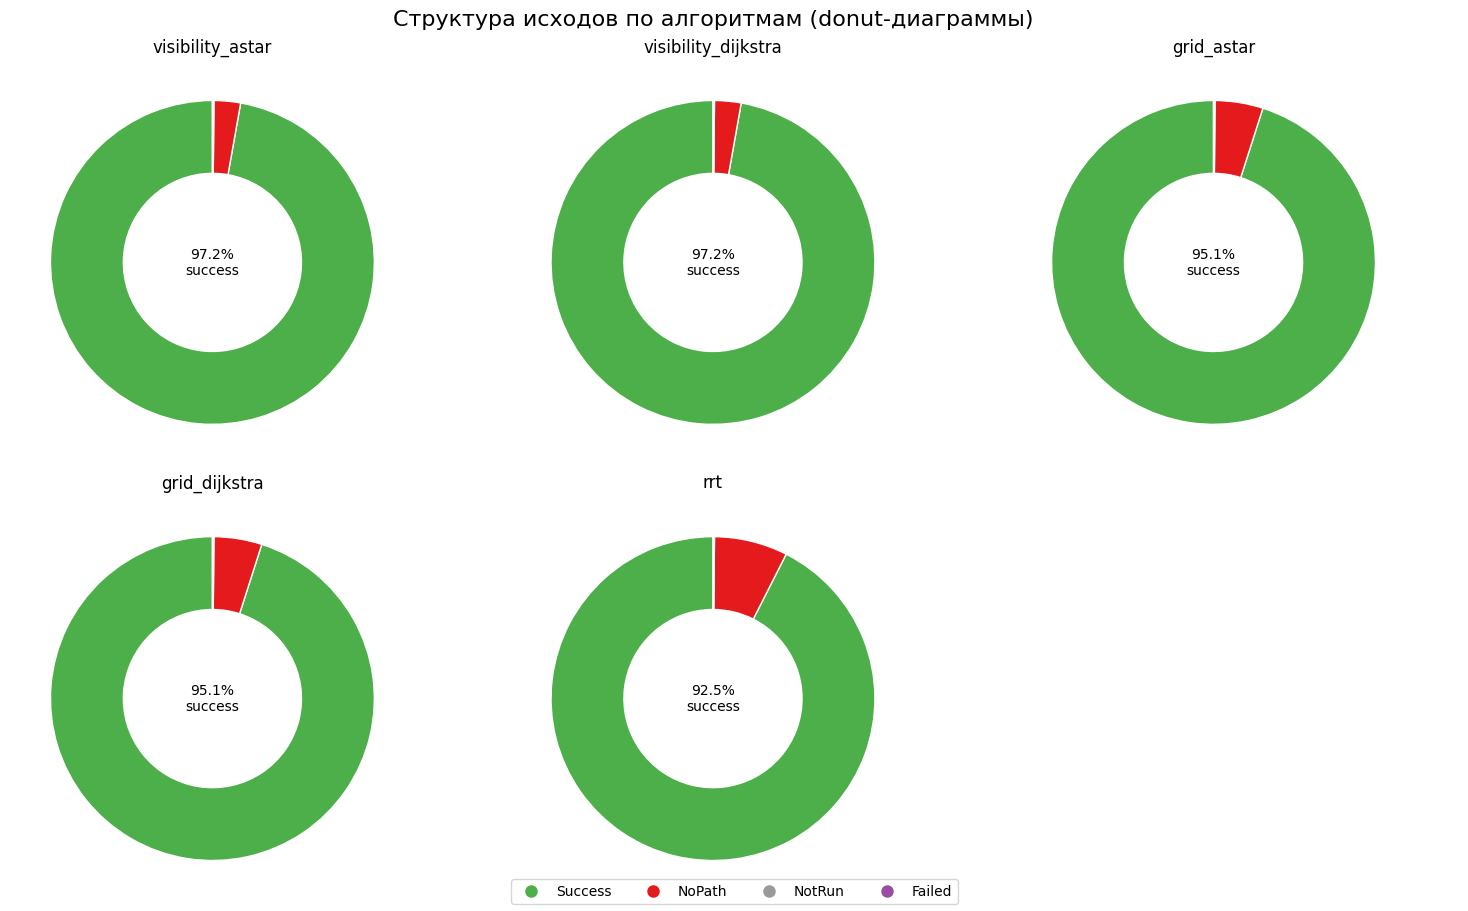

In [107]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.ravel()
status_colors = {'Success': '#4daf4a', 'NoPath': '#e41a1c', 'NotRun': '#999999', 'Failed': '#984ea3'}

for axis_index, algorithm_id in enumerate(plot_order):
    ax = axes[axis_index]
    status_counts = status_counts_df.loc[algorithm_id, STATUS_ORDER]
    labels = [label for label in STATUS_ORDER if status_counts[label] > 0]
    values = [status_counts[label] for label in labels]
    colors = [status_colors[label] for label in labels]

    ax.pie(
        values,
        startangle=90,
        colors=colors,
        wedgeprops={'width': 0.45, 'edgecolor': 'white'}
    )
    ax.set_title(algorithm_id)
    ax.text(
        0, 0,
        f"{status_counts['Success'] / status_counts.sum():.1%}\nsuccess",
        ha='center',
        va='center',
        fontsize=10
    )

axes[-1].axis('off')
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=status_colors[label], markersize=10)
    for label in status_colors
]
fig.legend(legend_handles, list(status_colors.keys()), loc='lower center', ncol=4)
fig.suptitle('Структура исходов по алгоритмам (donut-диаграммы)', fontsize=16)

outcome_donuts_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_outcome_donuts.png'
fig.savefig(outcome_donuts_path, dpi=180, bbox_inches='tight')
print('Saved:', outcome_donuts_path)
plt.show()

In [ ]:
runtime_winner_counts = config_runtime_winners_df['algorithm_id'].value_counts().reindex(plot_order, fill_value=0)
quality_winner_counts = config_quality_winners_df['algorithm_id'].value_counts().reindex(plot_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, counts, title in [
    (axes[0], runtime_winner_counts, 'Победители по времени'),
    (axes[1], quality_winner_counts, 'Победители по качеству пути'),
]:
    labels = counts.index.tolist()
    values = counts.values
    colors = [ALGORITHM_COLORS[label] for label in labels]
    ax.pie(values, labels=labels, autopct='%1.0f', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
    ax.set_title(title)

winner_pies_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_winner_pies.png'
fig.savefig(winner_pies_path, dpi=180, bbox_inches='tight')
print('Saved:', winner_pies_path)
plt.show()

один алгоритм доминирует по времени, другой -- по качеству пути

Saved: analysis_outputs\final25_algorithm_ecdf.png


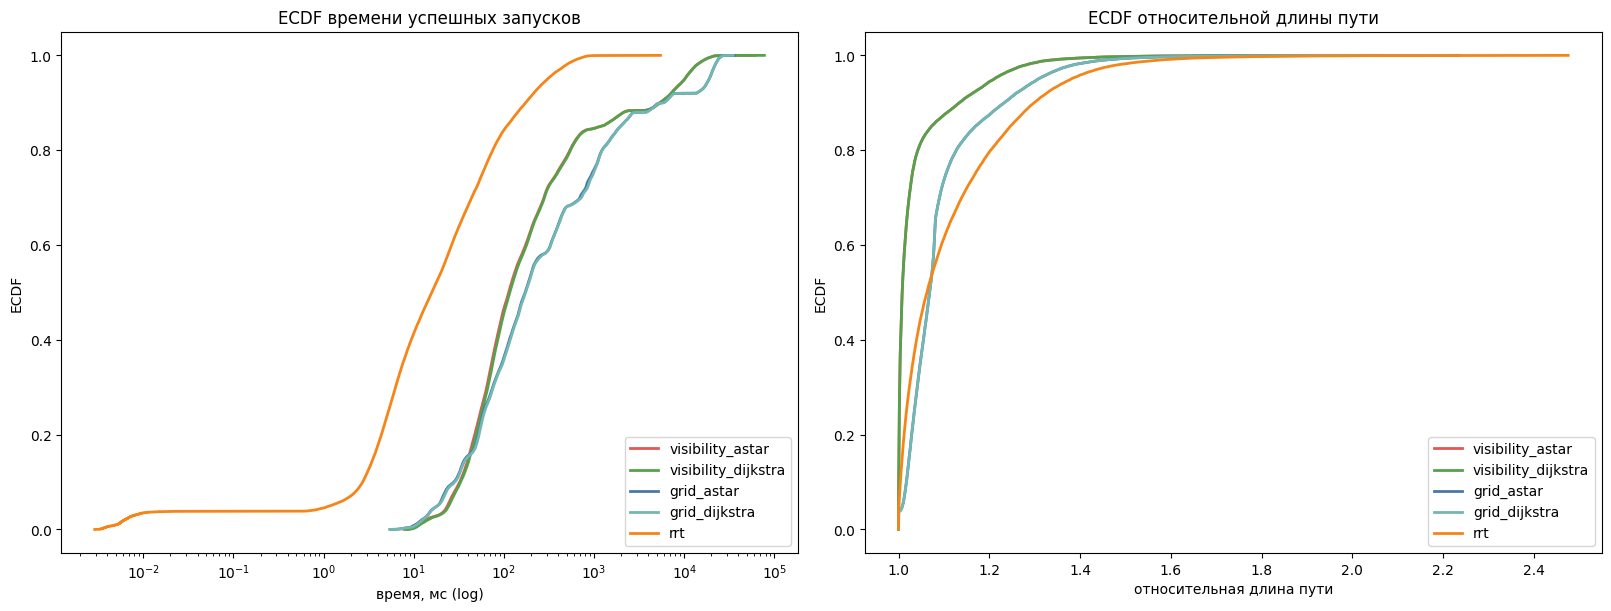

In [118]:
def build_ecdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(values) + 1) / len(values)
    return values, y

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for algorithm_id in plot_order:
    runtime_values = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'runtime_ms'].values
    x, y = build_ecdf(runtime_values)
    axes[0].plot(x, y, linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[0].set_xscale('log')
axes[0].set_title('ECDF времени успешных запусков')
axes[0].set_xlabel('время, мс (log)')
axes[0].set_ylabel('ECDF')
axes[0].legend(loc='lower right')

for algorithm_id in plot_order:
    quality_values = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'relative_path_length'].values
    x, y = build_ecdf(quality_values)
    axes[1].plot(x, y, linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('ECDF относительной длины пути')
axes[1].set_xlabel('относительная длина пути')
axes[1].set_ylabel('ECDF')
axes[1].legend(loc='lower right')

ecdf_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_ecdf.png'
fig.savefig(ecdf_path, dpi=180, bbox_inches='tight')
print('Saved:', ecdf_path)
plt.show()

показывают всю функцию распределения. Благодаря им можно судить о стабильности преимущества алгоритма, а не только о точечных статистиках вроде медианы.

Saved: analysis_outputs\final25_algorithm_runtime_quality_scatter.png


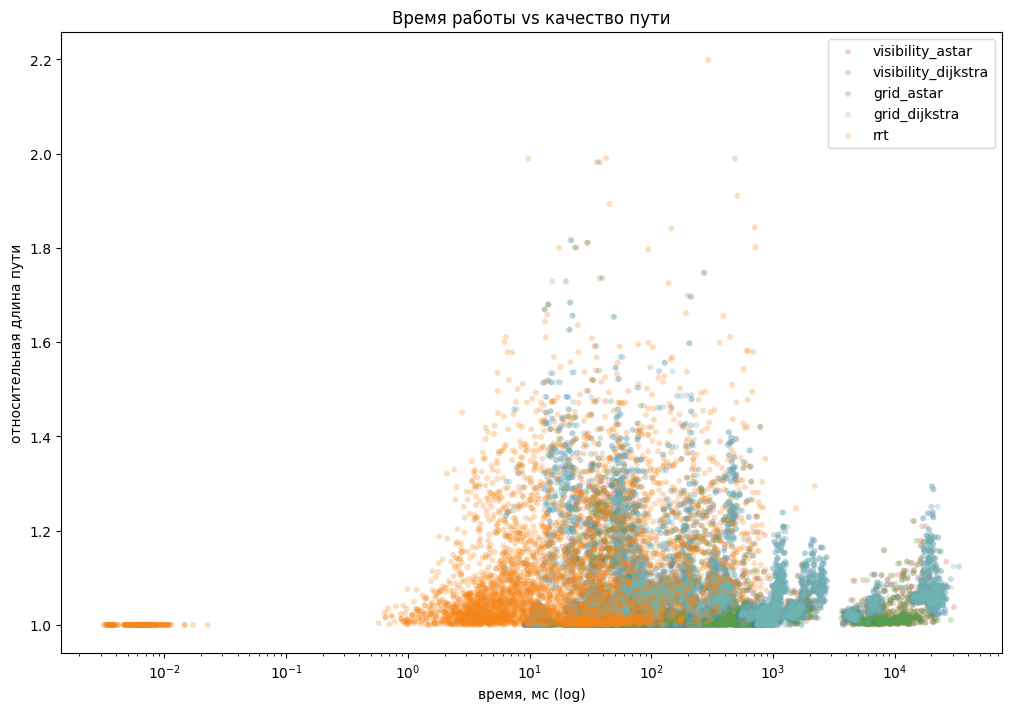

In [102]:
scatter_sample_df = SUCCESS_RUNS_DF.groupby('algorithm_id', group_keys=False).apply(lambda df: df.sample(min(len(df), 4000), random_state=42)).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
for algorithm_id in plot_order:
    algo_df = scatter_sample_df.loc[scatter_sample_df['algorithm_id'] == algorithm_id]
    ax.scatter(
        algo_df['runtime_ms'],
        algo_df['relative_path_length'],
        s=18,
        alpha=0.28,
        color=ALGORITHM_COLORS[algorithm_id],
        label=algorithm_id,
        edgecolors='none',
    )
ax.set_xscale('log')
ax.set_title('Время работы vs качество пути')
ax.set_xlabel('время, мс (log)')
ax.set_ylabel('относительная длина пути')
ax.legend(loc='upper right')

runtime_quality_scatter_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_quality_scatter.png'
fig.savefig(runtime_quality_scatter_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_quality_scatter_path)
plt.show()

Scatter-представление особенно хорошо показывает общее пространство trade-off между скоростью и качеством маршрута. По нему видно, какие алгоритмы ближе к «быстрой», а какие — к «качественной» части фронта решений.

In [119]:
summary_rows = []
for algorithm_id in plot_order:
    algo_corr_df = algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['algorithm_id'] == algorithm_id
    ].copy()

    top_success_row = algo_corr_df.iloc[algo_corr_df['success_spearman'].abs().argmax()]
    top_runtime_row = algo_corr_df.iloc[algo_corr_df['runtime_spearman'].abs().argmax()]
    top_quality_row = algo_corr_df.iloc[algo_corr_df['quality_spearman'].abs().argmax()]

    summary_rows.append({
        'algorithm_id': algorithm_id,
        'top_success_metric': SHORT_METRIC_LABELS[top_success_row['metric']],
        'top_success_corr': top_success_row['success_spearman'],
        'top_runtime_metric': SHORT_METRIC_LABELS[top_runtime_row['metric']],
        'top_runtime_corr': top_runtime_row['runtime_spearman'],
        'top_quality_metric': SHORT_METRIC_LABELS[top_quality_row['metric']],
        'top_quality_corr': top_quality_row['quality_spearman'],
    })

algorithm_summary_metrics_df = pd.DataFrame(summary_rows)

best_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmax()
weakest_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmin()
fastest_success_algorithm = algorithm_overview_df['median_runtime_success_ms'].idxmin()
best_quality_algorithm = algorithm_overview_df['median_relative_path_length'].idxmin()

summary_lines = [
    "# Итоговый анализ алгоритмов",
    "",
    "## Общая картина",
    "",
    f"- Наилучшую успешность показал **{best_success_algorithm}**: **{algorithm_overview_df.loc[best_success_algorithm, 'success_rate_executed']:.2%}**.",
    f"- Наименьшую успешность показал **{weakest_success_algorithm}**: **{algorithm_overview_df.loc[weakest_success_algorithm, 'success_rate_executed']:.2%}**.",
    f"- Самым быстрым по медианному времени успешного запуска оказался **{fastest_success_algorithm}**: **{algorithm_overview_df.loc[fastest_success_algorithm, 'median_runtime_success_ms']:.2f} мс**.",
    f"- Лучшее медианное качество пути показал **{best_quality_algorithm}**: **relative_path_length = {algorithm_overview_df.loc[best_quality_algorithm, 'median_relative_path_length']:.4f}**.",
    "",
    "## Основные выводы",
    "",
    "- **Visibility-планировщики** показывают лучшее сочетание надёжности и качества маршрута.",
    "- **RRT** выигрывает по времени, но уступает по успешности и стабильности качества пути.",
    "- **Grid-алгоритмы** занимают промежуточную позицию, но сильнее реагируют на рост размера сцены и длины маршрута.",
    "- На уровне отдельных конфигов не наблюдается одного безусловного лидера: эффективность алгоритма зависит от структуры сцены.",
    "",
    "## Связь с параметрами среды",
    "",
]

for _, row in algorithm_summary_metrics_df.iterrows():
    summary_lines.append(
        f"- Для **{row['algorithm_id']}**: успешность сильнее всего связана с **{row['top_success_metric']}** ({row['top_success_corr']:+.3f}), "
        f"время работы — с **{row['top_runtime_metric']}** ({row['top_runtime_corr']:+.3f}), "
        f"качество пути — с **{row['top_quality_metric']}** ({row['top_quality_corr']:+.3f})."
    )

summary_lines.extend([
    "",
    "## Общий вывод",
    "",
    "Результаты показывают, что универсально лучшего алгоритма по всем критериям нет. "
    "Если важнее надёжность и качество пути, предпочтительны visibility-подходы; "
    "если приоритетом является скорость, наиболее выгоден RRT; "
    "grid-алгоритмы можно рассматривать как компромиссный вариант.",
])

summary_md = "\n".join(summary_lines)

summary_md_path = OUTPUT_DIR / f"{DATASET_PREFIX}_algorithm_summary_ru.md"
summary_md_path.write_text(summary_md, encoding="utf-8")

print("Saved:", summary_md_path)
display(Markdown(summary_md))


Saved: analysis_outputs\final25_algorithm_summary_ru.md


# Итоговый анализ алгоритмов

## Общая картина

- Наилучшую успешность показал **visibility_astar**: **97.35%**.
- Наименьшую успешность показал **rrt**: **92.67%**.
- Самым быстрым по медианному времени успешного запуска оказался **rrt**: **15.86 мс**.
- Лучшее медианное качество пути показал **visibility_astar**: **relative_path_length = 1.0079**.

## Основные выводы

- **Visibility-планировщики** показывают лучшее сочетание надёжности и качества маршрута.
- **RRT** выигрывает по времени, но уступает по успешности и стабильности качества пути.
- **Grid-алгоритмы** занимают промежуточную позицию, но сильнее реагируют на рост размера сцены и длины маршрута.
- На уровне отдельных конфигов не наблюдается одного безусловного лидера: эффективность алгоритма зависит от структуры сцены.

## Связь с параметрами среды

- Для **visibility_astar**: успешность сильнее всего связана с **largest_component_ratio** (+0.270), время работы — с **scene_obstacle_count** (+0.957), качество пути — с **obstacle_area_ratio** (+0.813).
- Для **visibility_dijkstra**: успешность сильнее всего связана с **largest_component_ratio** (+0.270), время работы — с **scene_obstacle_count** (+0.953), качество пути — с **obstacle_area_ratio** (+0.813).
- Для **grid_astar**: успешность сильнее всего связана с **largest_component_ratio** (+0.346), время работы — с **scene_direct_distance** (+0.973), качество пути — с **obstacle_area_ratio** (+0.723).
- Для **grid_dijkstra**: успешность сильнее всего связана с **largest_component_ratio** (+0.346), время работы — с **scene_direct_distance** (+0.973), качество пути — с **obstacle_area_ratio** (+0.723).
- Для **rrt**: успешность сильнее всего связана с **largest_component_ratio** (+0.366), время работы — с **scene_direct_distance** (+0.662), качество пути — с **obstacle_area_ratio** (+0.737).

## Общий вывод

Результаты показывают, что универсально лучшего алгоритма по всем критериям нет. Если важнее надёжность и качество пути, предпочтительны visibility-подходы; если приоритетом является скорость, наиболее выгоден RRT; grid-алгоритмы можно рассматривать как компромиссный вариант.

Практические рекомендации
1. Если приоритетом является **максимальная вероятность найти путь** и **высокое качество маршрута**, следует предпочесть `visibility_astar`.,
2. Если приоритетом является **минимальное время отклика**, а небольшое снижение надёжности допустимо, наиболее целесообразен `rrt`.,
3. Если требуется более классический дискретный подход, можно использовать `grid_astar`, но следует учитывать его высокую чувствительность к росту размера сцены.,
4. Для тяжёлых и сильно загруженных конфигураций стоит особенно внимательно отслеживать `largest_component_ratio` и `obstacle_area_ratio`, так как именно они сильнее всего связаны с деградацией поведения алгоритмов.,
5. При построении стресс-сценариев полезно отдельно варьировать не только общую плотность препятствий, но и кластерность, ширину проходов и размер сцены: именно такая декомпозиция лучше раскрывает различия между алгоритмами.,
6. Для систем с несколькими режимами работы перспективен **адаптивный выбор алгоритма**: быстрый `rrt` на простых сценах и visibility-планировщик на сложных случаях.